# Green Space, Urban Heat, and Residential Equity in Metropolitan Melbourne

## 1. Introductnio
Urban green spaces are a vital component of the city environment, providing people with places for recreation, social interaction, and daily outdoor activities. At the same time, green spaces can help cool local areas by offering shade, increasing evapotranspiration, and reducing the proportion of hard, impermeable surfaces. In large, densely populated urban regions such as the Melbourne metropolitan area, the spatial distribution of green spaces is closely linked to residents' comfort, levels of urban heat exposure, and climate resilience.

However, the benefits of green spaces are not always evenly distributed. Some areas may have abundant parks, open spaces, and vegetation, while others struggle to access sufficient green resources. These disparities become even more pronounced when they overlap with social vulnerability—such as in areas with low income levels, high population density, or higher proportions of elderly and children.

This project investigates the spatial relationships among green spaces, urban thermal environments, and residential equity in the Melbourne metropolitan area. Using Statistical Area 2 (SA2) as the primary analytical unit, it integrates data on open spaces, urban heat conditions, vegetation, and census indicators from the Australian Bureau of Statistics. The analysis aims to examine whether green spaces are spatially equitably distributed, whether they are associated with lower heat exposure risks, and whether socially vulnerable areas are more likely to face both insufficient greenery and higher heat risks. The findings will support the identification of priority areas for future urban greening initiatives, improvements in public open spaces, and climate-resilience planning.areas.

## 2. Research Question

How are green space, urban heat exposure, and residential equity spatially related across Melbourne’s metropol

## 3. study area

The study area is the SA2 analysis area within Metropolitan Melbourne. It contains 360 SA2 units. All environmental and social indicators are aggregated to the SA2 level for comparison, mapping, and priority analysis.and mapping.

In [73]:
# Import libraries and set project paths

from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import seaborn as sns
import numpy as np
import rasterio
from rasterstats import zonal_stats
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Find the project root folder automatically
def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "data" / "raw").exists():
            return path
    raise FileNotFoundError("Project root folder was not found. Please check the folder structure.")

project_dir = find_project_root()

# Main folders
raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"
output_dir = project_dir / "outputs"

# Raw data folders
boundary_dir = raw_dir / "boundary"
census_dir = raw_dir / "census"
open_space_dir = raw_dir / "open_space"
urban_heat_dir = raw_dir / "urban_heat"

# Output folders
map_dir = output_dir / "maps"
chart_dir = output_dir / "charts"
table_dir = output_dir / "tables"

# Create output folders if they do not exist
for folder in [processed_dir, map_dir, chart_dir, table_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", project_dir)
print("Raw data folder:", raw_dir)
print("Processed data folder:", processed_dir)
print("Output folder:", output_dir)

Project directory: C:\Users\15483\Documents\GitHub\geom90006_a4
Raw data folder: C:\Users\15483\Documents\GitHub\geom90006_a4\data\raw
Processed data folder: C:\Users\15483\Documents\GitHub\geom90006_a4\data\processed
Output folder: C:\Users\15483\Documents\GitHub\geom90006_a4\outputs


In [23]:
# Load main datasets

greater_melb = gpd.read_file(boundary_dir / "greater_melbourne_boundary.gpkg")
sa2_full = gpd.read_file(boundary_dir / "sa2_greater_melbourne.gpkg")

# Final SA2 analysis area
sa2_analysis = gpd.read_file(boundary_dir / "sa2_analysis_area.gpkg")

open_space = gpd.read_file(open_space_dir / "open_space_melbourne.gpkg")
urban_heat = gpd.read_file(urban_heat_dir / "urban_heat.gpkg")

print("Greater Melbourne boundary:", greater_melb.shape)
print("Full SA2 boundary:", sa2_full.shape)
print("Final SA2 analysis area:", sa2_analysis.shape)
print("Open space:", open_space.shape)
print("Urban heat:", urban_heat.shape)

Greater Melbourne boundary: (1, 12)
Full SA2 boundary: (361, 18)
Final SA2 analysis area: (360, 19)
Open space: (38639, 22)
Urban heat: (55603, 20)


In [26]:
# Standardise CRS and calculate SA2 area

TARGET_CRS = "EPSG:7855"  # GDA2020 / MGA Zone 55, suitable for area calculation in Melbourne

greater_melb = greater_melb.to_crs(TARGET_CRS)
sa2_full = sa2_full.to_crs(TARGET_CRS)
sa2_analysis = sa2_analysis.to_crs(TARGET_CRS)
open_space = open_space.to_crs(TARGET_CRS)
urban_heat = urban_heat.to_crs(TARGET_CRS)

# Check geometry validity
print("Invalid geometries:")
print("Greater Melbourne boundary:", (~greater_melb.is_valid).sum())
print("Full SA2 boundary:", (~sa2_full.is_valid).sum())
print("Final SA2 analysis area:", (~sa2_analysis.is_valid).sum())
print("Open space:", (~open_space.is_valid).sum())
print("Urban heat:", (~urban_heat.is_valid).sum())

# Calculate SA2 area
sa2_analysis["area_m2"] = sa2_analysis.geometry.area
sa2_analysis["area_km2"] = sa2_analysis["area_m2"] / 1_000_000

sa2_analysis[["sa2_code", "sa2_name", "area_km2"]].head()

Invalid geometries:
Greater Melbourne boundary: 0
Full SA2 boundary: 0
Final SA2 analysis area: 0
Open space: 0
Urban heat: 0


,sa2_code,sa2_name,area_km2
0,213051362,Hoppers Crossing - South,7.012411
1,213051368,Werribee - South,114.061560
2,213051467,Werribee - East,7.758551
3,213051468,Werribee - West,59.916045
4,213051579,Manor Lakes - Quandong,14.935574


In [28]:
# Create SA2 master base dataset

sa2_master = sa2_analysis[[
    "sa2_code",
    "sa2_name",
    "area_m2",
    "area_km2",
    "geometry"
]].copy()

sa2_master = sa2_master.rename(columns={
    "sa2_code": "sa2_code",
    "sa2_name": "sa2_name"
})

# Save the master base dataset
sa2_master.to_file(
    processed_dir / "sa2_master_base.gpkg",
    layer="sa2_master_base",
    driver="GPKG"
)

print("SA2 master base saved successfully.")
print("Number of SA2 areas:", len(sa2_master))
sa2_master.head()

SA2 master base saved successfully.
Number of SA2 areas: 360


,sa2_code,sa2_name,area_m2,area_km2,geometry
0,213051362,Hoppers Crossing - South,7.012411e+06,7.012411,"MULTIPOLYGON (((294653.085 5806028.552, 294645..."
1,213051368,Werribee - South,1.140616e+08,114.061560,"MULTIPOLYGON (((300955.332 5798020.917, 300955..."
2,213051467,Werribee - East,7.758551e+06,7.758551,"MULTIPOLYGON (((292554.398 5804662.406, 292548..."
3,213051468,Werribee - West,5.991604e+07,59.916045,"MULTIPOLYGON (((288867.598 5797885.557, 288870..."
4,213051579,Manor Lakes - Quandong,1.493557e+07,14.935574,"MULTIPOLYGON (((281564.588 5805244.323, 284521..."


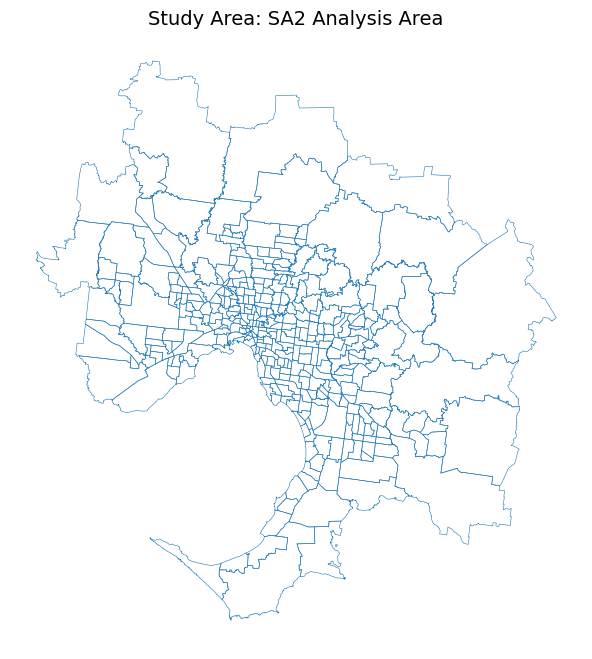

In [20]:
# Create final study area map

fig, ax = plt.subplots(figsize=(8, 8))

# Final SA2 analysis area
sa2_master.boundary.plot(
    ax=ax,
    linewidth=0.4
)

ax.set_title("Study Area: SA2 Analysis Area", fontsize=14)
ax.set_axis_off()

plt.savefig(
    map_dir / "study_area_sa2_analysis_area.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The study area used in this project is the SA2 analysis area within Metropolitan Melbourne. It contains 360 SA2 units and provides the common spatial framework for integrating open space, urban heat, and Census-based social equity indicators.

## 4. Data Sources

This project uses four main groups of datasets:

- **SA2 boundary data**: used as the main spatial analysis unit.
- **ABS Census 2021 data**: used to represent population and social equity indicators.
- **VPA Open Space data**: used to measure the distribution of open space across SA2 areas.
- **Urban Heat and Vegetation 2018 data**: used to represent heat exposure and vegetation-related environmenta
## 5. Data preprocessing

The preprocessing steps include:

1. Loading the boundary, Census, open space, and urban heat datasets.
2. Using the SA2 analysis area as the common study area.
3. Reprojecting all spatial datasets to EPSG:7855 for area-based calculation.
4. Checking invalid geometries in the spatial datasets.
5. Calculating the area of each SA2 unit.
6. Creating a master SA2 base dataset for later analysis.

The final SA2 master base contains SA2 code, SA2 name, area, and geometry. It will be used to join green space, urban heat, and Census-based social equity indicators in the following analysis.nalysis. analysis

## 6. Green Space and Urban Heat Analysis

This section analyses the relationship between open space distribution and urban heat exposure across the SA2 analysis area. Open space coverage and urban heat indicators are aggregated to the SA2 level and then compared using maps, summary statistics, and correlation analysis.

### 6.1 Exploratory Spatial Data Analysis (ESDA)

This section presents the exploratory spatial data analysis of the main environmental and social variables used in the project. 

Urban heat is one of the most significant environmental challenges facing contemporary cities. Green infrastructure, particularly public open space and tree density, have been widely recognised as an effective strategy for mitigating urban heat. This analysis investigates the relationship between open space coverage and urban heat intensity across Greater Melbourne using spatial analytical techniques

In [41]:
# Use prepared datasets from the main notebook

sa2 = sa2_analysis.copy()
open_space = open_space.copy()

print(sa2.shape)
print(open_space.shape)
sa2.head()

(360, 20)
(38639, 22)


,id,sa2_code,sa2_name,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,GCCSA_NAME_2021,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,area_km2,geometry,area_m2
0,1081,213051362,Hoppers Crossing - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.0114,http://linked.data.gov.au/dataset/asgsed3/SA2/...,7.012411,"MULTIPOLYGON (((294653.085 5806028.552, 294645...",7.012411e+06
1,1083,213051368,Werribee - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,114.0332,http://linked.data.gov.au/dataset/asgsed3/SA2/...,114.061560,"MULTIPOLYGON (((300955.332 5798020.917, 300955...",1.140616e+08
2,1086,213051467,Werribee - East,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.7569,http://linked.data.gov.au/dataset/asgsed3/SA2/...,7.758551,"MULTIPOLYGON (((292554.398 5804662.406, 292548...",7.758551e+06
3,1087,213051468,Werribee - West,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,127.6631,http://linked.data.gov.au/dataset/asgsed3/SA2/...,59.916045,"MULTIPOLYGON (((288867.598 5797885.557, 288870...",5.991604e+07
4,1088,213051579,Manor Lakes - Quandong,1,New,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,72.0339,http://linked.data.gov.au/dataset/asgsed3/SA2/...,14.935574,"MULTIPOLYGON (((281564.588 5805244.323, 284521...",1.493557e+07


Number of SA2 areas: 360


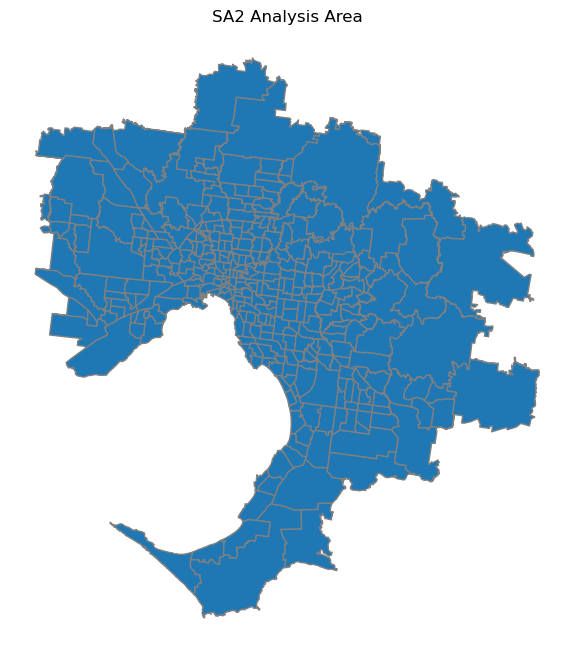

In [43]:
# Quick check of SA2 analysis area

melb = sa2_analysis.copy()

print("Number of SA2 areas:", len(melb))

melb.plot(
    figsize=(8, 8),
    edgecolor="grey"
)

plt.title("SA2 Analysis Area")
plt.axis("off")
plt.show()

#### 6.1.1 Summary Statistics of Green Space and Urban Heat Indicators

The completed Q2 dataset contains SA2-level indicators for green space coverage, open space area, urban heat, and tree density. This section summarises the distribution of these indicators before further spatial analysis.

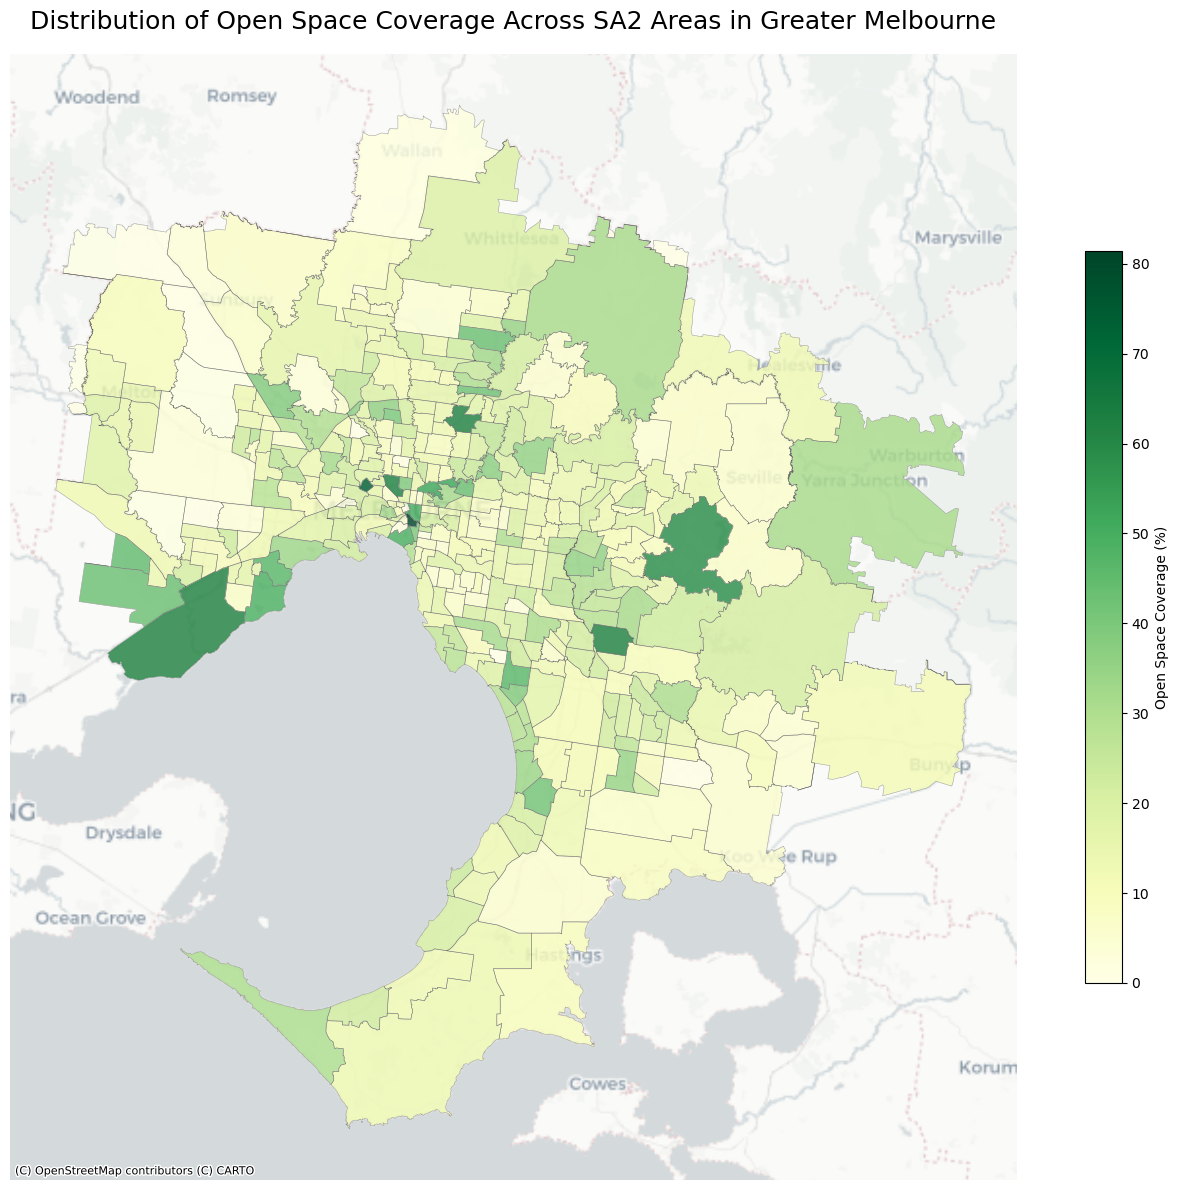

In [51]:
melb_map = melb.to_crs(3857)

fig, ax = plt.subplots(
    figsize=(14, 12)
)

melb_map.plot(
    column="coverage",
    cmap="YlGn",
    linewidth=0.35,
    edgecolor="white",
    alpha=0.82,
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Open Space Coverage (%)",
        "shrink": 0.65
    }
)

melb_map.boundary.plot(
    ax=ax,
    linewidth=0.4,
    color="black",
    alpha=0.35
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title(
    "Distribution of Open Space Coverage Across SA2 Areas in Greater Melbourne",
    fontsize=18,
    pad=18
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    "green_space_formative.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation

This map presents the spatial distribution of open space coverage across SA2 areas in Greater Melbourne. The results indicate substantial variation in the proportion of land allocated to open space throughout the metropolitan region.

Higher open space coverage appears in several outer metropolitan and peripheral areas, while many inner and middle-ring suburbs display lower proportions. This pattern may be associated with differences in development intensity, land use allocation, and the availability of large public reserves.

In relation to the research question, the findings suggest that green space is not evenly distributed across Greater Melbourne. Although this map focuses only on spatial coverage, it provides an initial indication of potential inequality in environmental amenity and accessibility. Future analysis may incorporate population data to evaluate green space per capita and better assess distribution equity.

### Open Space Coverage Calculation

This step calculates the proportion of open space within each SA2 area. The open space polygons are intersected with the SA2 analysis area, and the total open space area is summarised for each SA2. Open space coverage is then calculated as the percentage of each SA2 covered by open space.

In [44]:
# Calculate open space coverage by SA2

melb = sa2_analysis.copy()
open_space_calc = open_space.copy()

melb = melb.to_crs(epsg=7855)
open_space_calc = open_space_calc.to_crs(epsg=7855)

melb["sa2_area"] = melb.geometry.area

overlay = gpd.overlay(
    open_space_calc,
    melb[
        [
            "sa2_code",
            "geometry"
        ]
    ],
    how="intersection"
)

overlay["open_area"] = overlay.geometry.area

summary = (
    overlay
    .groupby("sa2_code")["open_area"]
    .sum()
    .reset_index()
)

melb = melb.merge(
    summary,
    on="sa2_code",
    how="left"
)

melb["open_area"] = melb["open_area"].fillna(0)

melb["coverage"] = (
    melb["open_area"] /
    melb["sa2_area"]
) * 100

melb.head()

,id,sa2_code,sa2_name,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,...,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,area_km2,geometry,area_m2,sa2_area,open_area,coverage
0,1081,213051362,Hoppers Crossing - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,AUS,Australia,7.0114,http://linked.data.gov.au/dataset/asgsed3/SA2/...,7.012411,"MULTIPOLYGON (((294653.085 5806028.552, 294645...",7.012411e+06,7.012411e+06,8.268239e+05,11.790865
1,1083,213051368,Werribee - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,AUS,Australia,114.0332,http://linked.data.gov.au/dataset/asgsed3/SA2/...,114.061560,"MULTIPOLYGON (((300955.332 5798020.917, 300955...",1.140616e+08,1.140616e+08,7.032759e+07,61.657575
2,1086,213051467,Werribee - East,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,AUS,Australia,7.7569,http://linked.data.gov.au/dataset/asgsed3/SA2/...,7.758551,"MULTIPOLYGON (((292554.398 5804662.406, 292548...",7.758551e+06,7.758551e+06,1.657223e+06,21.359952
3,1087,213051468,Werribee - West,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,AUS,Australia,127.6631,http://linked.data.gov.au/dataset/asgsed3/SA2/...,59.916045,"MULTIPOLYGON (((288867.598 5797885.557, 288870...",5.991604e+07,5.991604e+07,2.559582e+07,42.719471
4,1088,213051579,Manor Lakes - Quandong,1,New,21305,Wyndham,213,Melbourne - West,2GMEL,...,AUS,Australia,72.0339,http://linked.data.gov.au/dataset/asgsed3/SA2/...,14.935574,"MULTIPOLYGON (((281564.588 5805244.323, 284521...",1.493557e+07,1.493557e+07,6.630091e+06,44.391269


In [59]:
# Load prepared Q2 green space and urban heat dataset

q2_path = processed_dir / "q2_green_heat_with_tree_count.gpkg"

q2 = gpd.read_file(q2_path)

print("Prepared Q2 dataset with tree count:", q2.shape)
q2.head()

Prepared Q2 dataset with tree count: (257, 9)


,sa2_code,sa2_name,coverage,open_area,UHI18_M,tree_density,area_km2,tree_count,geometry
0,213051362,Hoppers Crossing - South,11.790865,8.268239e+05,8.385504,3050.020758,7.012411,21388,"MULTIPOLYGON (((16104078.525 -4561091.453, 161..."
1,213051368,Werribee - South,61.657575,7.032759e+07,6.900058,456.849792,114.061560,52109,"MULTIPOLYGON (((16111802.697 -4571463.547, 161..."
2,213051467,Werribee - East,21.359952,1.657223e+06,7.630220,3108.183493,7.758551,24115,"MULTIPOLYGON (((16101380.797 -4562759.439, 161..."
3,213051468,Werribee - West,42.719471,2.559582e+07,8.069294,411.225408,59.916045,24639,"MULTIPOLYGON (((16096496.805 -4571250.532, 160..."
4,214021383,Point Nepean,30.647845,2.059349e+07,3.073223,734.992220,67.193908,49387,"MULTIPOLYGON (((16125943.474 -4643363.334, 161..."


In [60]:
q2[["tree_count", "tree_density", "coverage", "UHI18_M"]].describe()

,tree_count,tree_density,coverage,UHI18_M
count,257.000000,257.000000,257.000000,257.000000
mean,27934.595331,2664.328122,18.383258,8.266447
std,27558.029601,1229.724051,12.299425,1.828274
min,0.000000,0.000000,0.000000,0.029429
25%,12021.000000,1843.198563,10.025083,7.517670
50%,20545.000000,2770.123184,16.070639,8.398132
75%,30817.000000,3644.043012,22.591331,9.373265
max,175247.000000,5041.707885,74.079449,11.716022


From the output, we can see that the average number of trees in each SA2 area of ​​Melbourne is approximately 27,935, with an average tree density of 2,664 trees per square kilometer. Extreme values ​​were observed: some SA2 areas had zero trees and a density of zero, while the ecologically best-preserved areas had a total of 175,247 trees and a density of 5,041 trees per square kilometer, indicating an extremely uneven distribution of green canopy resources throughout the city.

We can also see that the distribution of green space in Melbourne is severely polarized, with over 75% of suburbs having a green coverage rate of less than 22.59%, and only a very few marginal eco-zones possessing exceptionally high green coverage. The urban heat island effect is a systemic crisis, with over 75% of the area experiencing an average temperature range exceeding 7.52°C, meaning the vast majority of residents face extremely high heat exposure risks during the summer.

#### 6.1.2 Histogram

* Tree Density Histogram

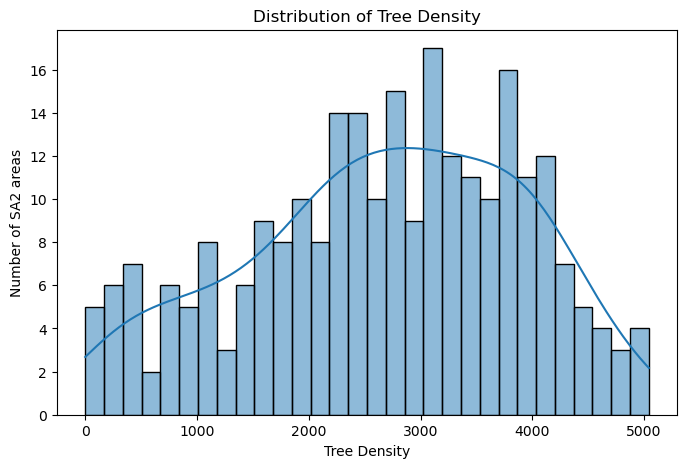

In [77]:
plt.figure(figsize=(8, 5))

sns.histplot(
    tree_density_data,
    bins=30,
    kde=True
)

plt.title("Distribution of Tree Density")
plt.xlabel("Tree Density")
plt.ylabel("Number of SA2 areas")

plt.savefig(
    chart_dir / "hist_tree_density.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The histogram shows that the tree density in the SA2 areas of Melbourne follows an approximately normal distribution, with the data mainly concentrated between 2,000 and 4,000 trees per square kilometer, indicating that most areas have a medium to high level of green coverage.

* Open Space Coverage Histogram

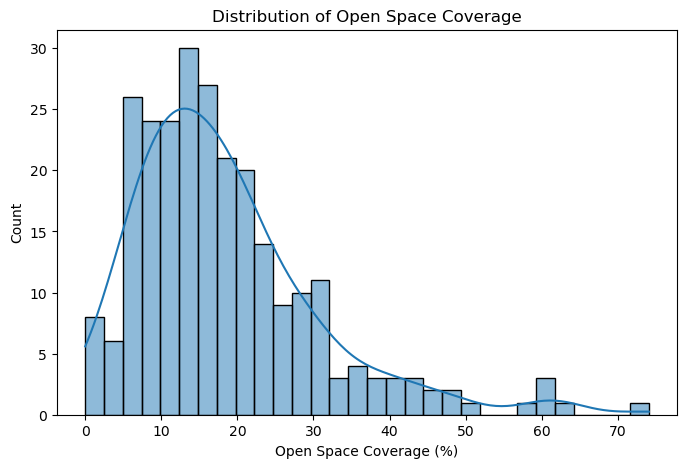

In [75]:
# Open space coverage histogram

coverage_data = (
    q2["coverage"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

plt.figure(figsize=(8, 5))

sns.histplot(
    coverage_data,
    bins=30,
    kde=True
)

plt.title("Distribution of Open Space Coverage")
plt.xlabel("Open Space Coverage (%)")
plt.ylabel("Count")

plt.savefig(
    chart_dir / "hist_open_space_coverage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The histogram of open space coverage reveals a highly right-skewed distribution across the SA2 statistical units in Greater Melbourne.

The majority of SA2 areas have relatively low to moderate open space coverage, mainly between 5% and 20%. The peak of the distribution occurs around 12% to 15%, indicating that many SA2 areas have limited open space coverage. The distribution curve also has a long right tail, with some areas reaching over 70% coverage. These high values are likely to represent a small number of low-density fringe areas or areas close to major protected landscapes and national parks, such as the Yarra Range or Dandenong Mountain areas.

* Urban Heat Histogram

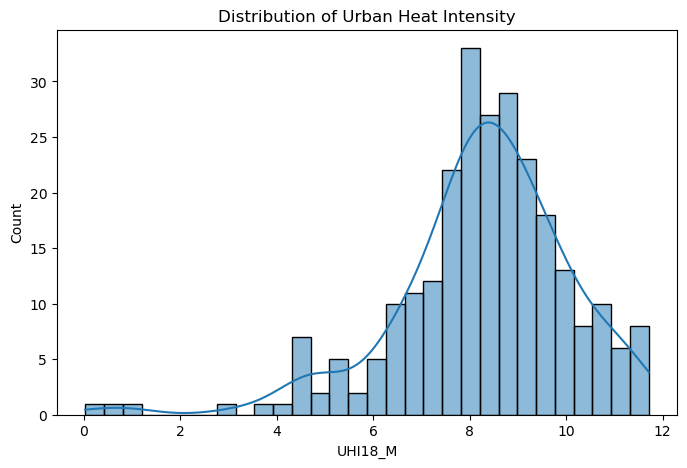

In [76]:
# Urban heat histogram

uhi_data = (
    q2["UHI18_M"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

plt.figure(figsize=(8, 5))

sns.histplot(
    uhi_data,
    bins=30,
    kde=True
)

plt.title("Distribution of Urban Heat Intensity")
plt.xlabel("UHI18_M")
plt.ylabel("Count")

plt.savefig(
    chart_dir / "hist_urban_heat_intensity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The histogram for Urban Heat Island intensity (UHI18_M) shows a negatively skewed distribution, which contrasts with the open space coverage distribution.

Most SA2 areas are concentrated in the higher UHI range, with the main peak between approximately 7.5 and 9.5. This suggests that urban heat intensity is a common environmental pressure across many residential SA2 areas in Greater Melbourne.

Only a small number of SA2 areas have very low UHI values. These lower-heat areas may correspond to locations with higher open space coverage, larger reserves, or stronger vegetation presence. This pattern provides preliminary evidence that areas with more green space may experience relatively lower urban heat intensity.

The contrast between the open space coverage histogram and the urban heat histogram supports further analysis of the relationship between green space and heat exposure.

#### 6.1.3 Pivot Tables

In [79]:
# Top 10 hottest SA2 areas

pivot_heat = (
    q2[["sa2_name", "UHI18_M"]]
    .sort_values("UHI18_M", ascending=False)
    .head(10)
)

pivot_heat

,sa2_name,UHI18_M
43,Burnside Heights,11.716022
208,Cranbourne,11.665816
40,Sydenham,11.574009
100,Cairnlea,11.566726
245,Narre Warren - North East,11.466223
7,Melton West,11.451552
37,Delahey,11.409298
111,Burnside,11.348166
124,Moorabbin Airport,11.302094
28,Essendon Airport,11.219677


The top 10 hottest SA2 areas are mainly concentrated in western and south-eastern parts of Greater Melbourne, including areas such as Burnside Heights, Sydenham, Cairnlea, Melton West, Cranbourne and Narre Warren. These areas show relatively high urban heat intensity values compared with other SA2 areas.

Several of these areas are rapidly developing outer or middle suburban areas. This result provides useful evidence for the later equity analysis, as it helps identify whether areas with stronger heat exposure also overlap with socially vulnerable communities.

In [80]:
# Divide tree density into 5 groups

q2["tree_density_group"] = pd.qcut(
    q2["tree_density"],
    5,
    labels=["Low", "medium_low", "Medium", "medium_high", "High"],
    duplicates="drop"
)

# Average UHI by tree density group
pivot_tree_density = pd.pivot_table(
    q2,
    values="UHI18_M",
    index="tree_density_group",
    aggfunc="mean"
)

pivot_tree_density

,UHI18_M
tree_density_group,
Low,7.676172
medium_low,8.951472
Medium,8.614757
medium_high,8.369604
High,7.742087


Across the tree density groups, the average urban heat intensity remains relatively high, but it fluctuates across the groups rather than showing a simple linear decline. This suggests that tree density alone may not fully explain urban heat variation across SA2 areas.

The result indicates that the relationship between tree density and heat exposure is likely affected by other factors, such as land use, built-up density, impervious surfaces, and the spatial arrangement of vegetation.

In [81]:
# Divide open space coverage into 5 groups

q2["coverage_group"] = pd.qcut(
    q2["coverage"],
    5,
    labels=["Low", "medium_low", "Medium", "medium_high", "High"],
    duplicates="drop"
)

# Average UHI by open space coverage group
pivot_coverage = pd.pivot_table(
    q2,
    values="UHI18_M",
    index="coverage_group",
    aggfunc="mean"
)

pivot_coverage

,UHI18_M
coverage_group,
Low,8.209160
medium_low,8.249160
Medium,8.365996
medium_high,8.143713
High,8.363429


Across the open space coverage groups, the average urban heat intensity remains within a relatively narrow range. The relationship is not a simple linear pattern where higher open space coverage always corresponds to lower heat intensity.

This suggests that urban heat in Greater Melbourne is influenced by broader spatial and built-environment factors. While open space can provide local cooling benefits, green space coverage alone may not be sufficient to explain all variation in urban heat intensity. A more complete interpretation needs to consider tree density, land surface characteristics, urban form, and social vulnerability together.

#### 6.1.4 Spatial Comparison Map

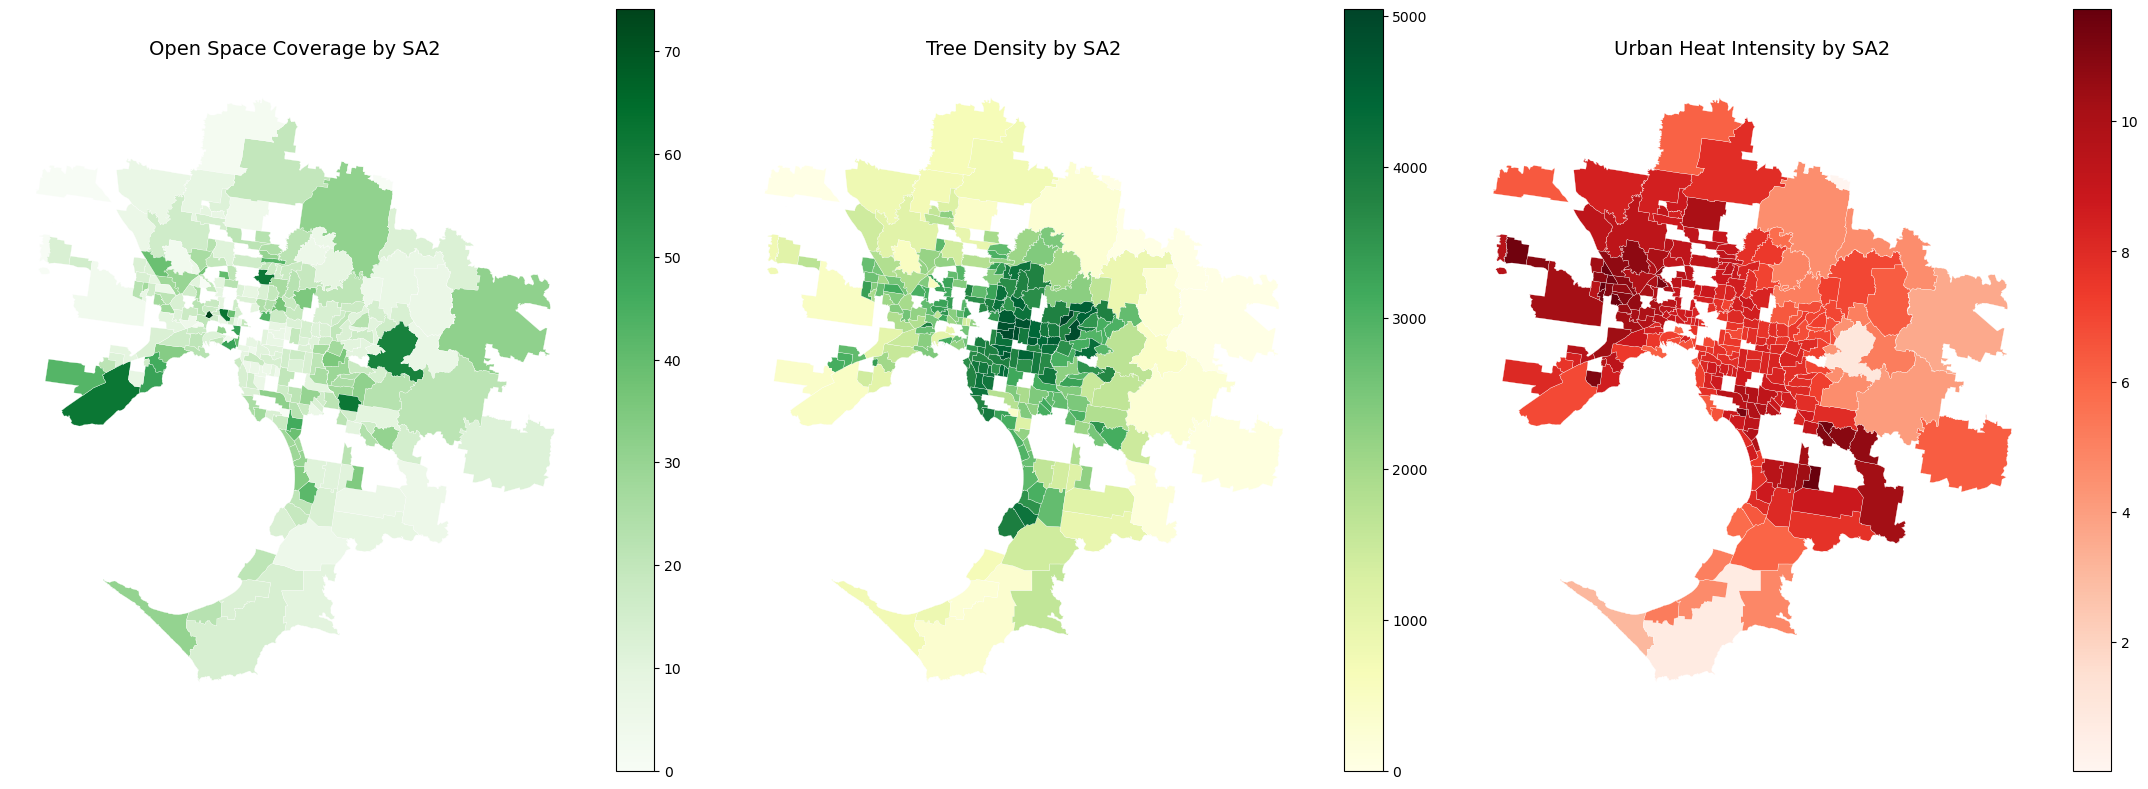

In [82]:
# Spatial comparison map of green cover, tree density and urban heat

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 8))

# Open space coverage
q2.plot(
    column="coverage",
    cmap="Greens",
    legend=True,
    ax=ax1,
    edgecolor="white",
    linewidth=0.2
)
ax1.set_title("Open Space Coverage by SA2", fontsize=14, pad=10)
ax1.set_axis_off()

# Tree density
q2.plot(
    column="tree_density",
    cmap="YlGn",
    legend=True,
    ax=ax2,
    edgecolor="white",
    linewidth=0.2
)
ax2.set_title("Tree Density by SA2", fontsize=14, pad=10)
ax2.set_axis_off()

# Urban heat intensity
q2.plot(
    column="UHI18_M",
    cmap="Reds",
    legend=True,
    ax=ax3,
    edgecolor="white",
    linewidth=0.2
)
ax3.set_title("Urban Heat Intensity by SA2", fontsize=14, pad=10)
ax3.set_axis_off()

plt.tight_layout()

plt.savefig(
    map_dir / "map_green_tree_heat_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The three maps compare the spatial patterns of open space coverage, tree density and urban heat intensity across SA2 areas. The open space coverage map and tree density map show that green resources are not evenly distributed across Greater Melbourne. Some outer and fringe areas have relatively high open space coverage, while many inner, western and northern areas show lower green coverage or lower tree density.

The urban heat intensity map shows that higher heat values are concentrated in several western, northern and south-eastern SA2 areas. When compared with the green space and tree density maps, some high-heat areas also appear to have relatively limited tree density or open space coverage. This suggests that green infrastructure may be related to local cooling conditions, although the spatial pattern is not entirely explained by green space alone.

Overall, the comparison indicates that urban heat exposure is likely influenced by a combination of factors, including open space coverage, tree density, land use, built-up density and surface materials. Therefore, future urban heat mitigation should consider both the amount of green space and the spatial distribution of trees and vegetation.

### 6.2 Green Space, Tree Density and Urban Heat Correlation Analysis

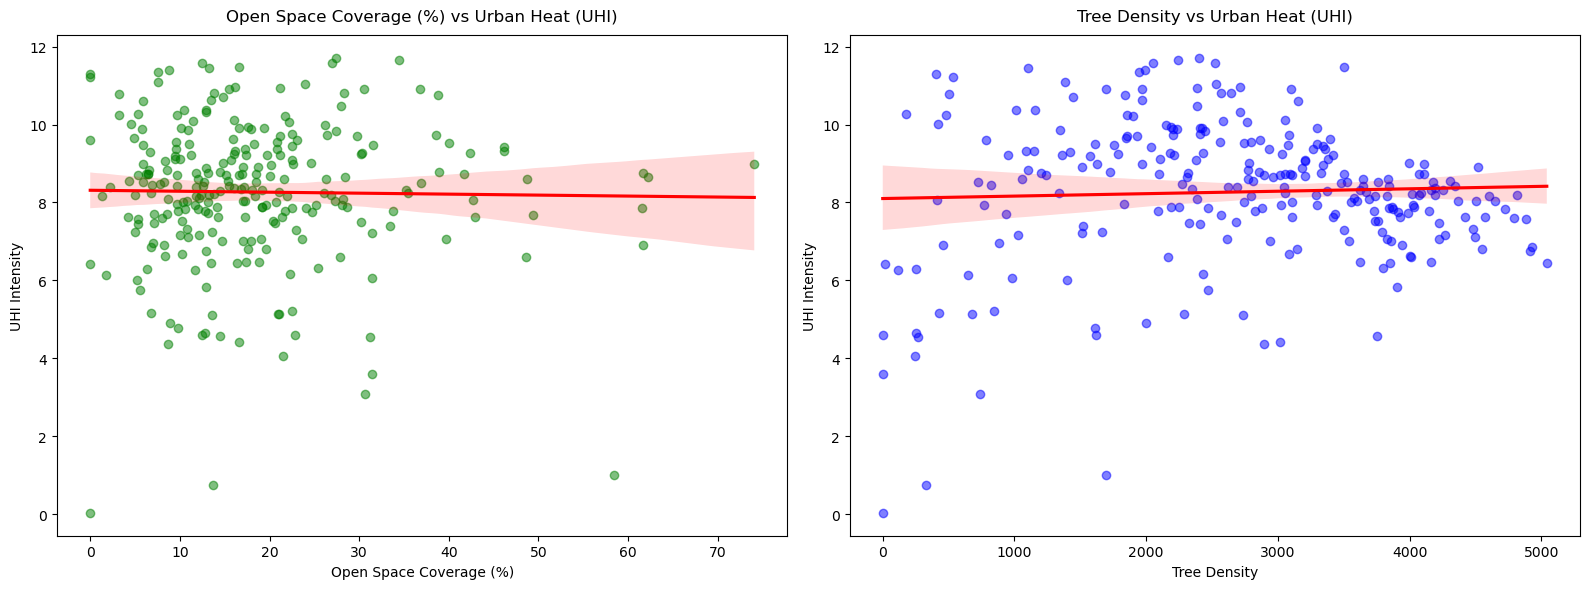

In [84]:
# Correlation analysis between green space, tree density and urban heat

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Open space coverage vs UHI
sns.regplot(
    x="coverage",
    y="UHI18_M",
    data=q2,
    ax=ax1,
    scatter_kws={"alpha": 0.5, "color": "green"},
    line_kws={"color": "red"}
)

ax1.set_title("Open Space Coverage (%) vs Urban Heat (UHI)", fontsize=12, pad=10)
ax1.set_xlabel("Open Space Coverage (%)")
ax1.set_ylabel("UHI Intensity")

# Tree density vs UHI
sns.regplot(
    x="tree_density",
    y="UHI18_M",
    data=q2,
    ax=ax2,
    scatter_kws={"alpha": 0.5, "color": "blue"},
    line_kws={"color": "red"}
)

ax2.set_title("Tree Density vs Urban Heat (UHI)", fontsize=12, pad=10)
ax2.set_xlabel("Tree Density")
ax2.set_ylabel("UHI Intensity")

plt.tight_layout()

plt.savefig(
    chart_dir / "correlation_green_tree_uhi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The regression plots show that the linear relationships between green space indicators and urban heat intensity are relatively weak at the SA2 level. The trend line between open space coverage and UHI18_M is nearly horizontal, suggesting that open space coverage alone does not strongly explain variations in urban heat intensity across all SA2 areas.

The relationship between tree density and UHI18_M also appears weak and non-linear. Some areas with higher tree density have lower heat intensity, but the overall pattern is scattered. This indicates that tree density may contribute to local cooling, but it is not the only factor influencing urban heat.

These results suggest that urban heat in Greater Melbourne is shaped by multiple factors, including green space coverage, tree density, land use, built-up density, impervious surfaces and local urban form. Therefore, the cooling effect of green infrastructure should be interpreted together with broader spatial and environmental conditions.

### 6.3 Spatial Autocorrelation Analysis: Moran's I

#### 6.3.1 Global Moran's I

In [87]:
from libpysal.weights import Queen
from esda.moran import Moran

w = Queen.from_dataframe(q2, use_index=False)
w.transform = "r"

moran_uhi = Moran(q2["UHI18_M"], w)

print(f"Moran's I: {moran_uhi.I:.4f}")
print(f"P-value:   {moran_uhi.p_sim:.4f}")

Moran's I: 0.7530
P-value:   0.0010


Global Moran's I was used to examine whether urban heat intensity shows spatial clustering across the SA2 areas. The result shows a Moran's I value of approximately 0.7530 with a p-value of 0.0010. This indicates a strong and statistically significant positive spatial autocorrelation in UHI18_M.

In other words, SA2 areas with high urban heat intensity tend to be located near other high-heat areas, while lower-heat areas also tend to cluster spatially. This result suggests that urban heat is not randomly distributed across Greater Melbourne, but forms clear regional spatial patterns.

#### 6.3.2 Bivariate Moran's I
Bivariate Moran's I is used to measure the spatial correlation between two different variables, assessing whether a local observation of one variable is significantly influenced by another variable in its surrounding neighborhood.

* Green Space Coverage

In [90]:
from esda.moran import Moran_BV

mbv_coverage = Moran_BV(q2["coverage"], q2["UHI18_M"], w)

print(f"Moran's I: {mbv_coverage.I:.4f}")
print(f"P-value:   {mbv_coverage.p_sim:.4f}")

Moran's I: 0.0534
P-value:   0.0700


The bivariate Moran's I between open space coverage and surrounding urban heat intensity is relatively weak, with a Moran's I value of approximately 0.0534. The p-value is around 0.0580, which is slightly above the 0.05 significance threshold. Therefore, this result does not provide strong statistical evidence of a significant spatial association at the 5% level.

This suggests that the spatial relationship between open space coverage and nearby urban heat is weak at the SA2 scale. Open space may still provide local cooling benefits, but its effect may be influenced by broader factors such as land use, built-up density, impervious surfaces and regional heat patterns.

* Tree Density

In [91]:
mbv_density = Moran_BV(q2["tree_density"], q2["UHI18_M"], w)

print(f"Moran's I: {mbv_density.I:.4f}")
print(f"P-value:   {mbv_density.p_sim:.4f}")

Moran's I: 0.0415
P-value:   0.2220


The bivariate Moran's I between tree density and surrounding urban heat intensity is also weak, with a Moran's I value of approximately 0.0415 and a p-value of around 0.2350. This indicates that the spatial cross-correlation between tree density and urban heat is not statistically significant.

This does not mean that trees have no cooling effect. Instead, it suggests that at the SA2 scale, tree density alone does not strongly explain the spatial distribution of urban heat. The cooling effect of trees may be more localised and may depend on tree canopy structure, land surface materials, building density and the spatial arrangement of vegetation.

### 6.4 Land Cover Fraction Analysis:SA2-Level Land Cover Fractions from Raster Data

This section uses the 25m resolution Victorian Land Cover Time Series raster to derive SA2-level fractions of key land cover types via zonal statistics.

The following composite variables are created:
- tree_total_frac: sum of scattered trees (code 5), treed native (12), and urban vegetation (6)
- grass_total_frac: sum of native grassland (7) and exotic pasture/grass (8)
- built_frac: built environment (code 4)
- water_frac: water bodies (code 1)
- bare_frac: sum of native bare ground (2) and non‑native bare ground (3)

In [99]:
# Load land cover raster
raster_path = raw_dir / "landcover.tif"

# Match q2 CRS with raster CRS
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

q2_projected = q2.to_crs(raster_crs)

# Perform zonal statistics
zonal_results = zonal_stats(
    q2_projected,
    raster_path,
    categorical=True
)

print("Number of SA2 polygons:", len(q2_projected))
print("Number of zonal results:", len(zonal_results))
print("First zonal result:", zonal_results[0])

Number of SA2 polygons: 257
Number of zonal results: 257
First zonal result: {1: 232, 2: 10252, 3: 137, 4: 55, 5: 28, 6: 1, 8: 308, 10: 85, 11: 39, 12: 32, 13: 12, 14: 17, 18: 2}


In [100]:
# Define land cover class codes
codes = {
    "water": 1,
    "scattered_trees": 5,
    "urban_veg": 6,
    "grass_native": 7,
    "grass_exotic": 8,
    "treed_native": 12,
    "built": 4,
    "bare_native": 2,
    "bare_not_native": 3
}

# Initialise fraction lists
tree_total_frac = []
grass_total_frac = []
built_frac = []
water_frac = []
bare_frac = []

for zone in zonal_results:
    total = sum(zone.values())

    if total == 0:
        tree_total_frac.append(0)
        grass_total_frac.append(0)
        built_frac.append(0)
        water_frac.append(0)
        bare_frac.append(0)
        continue

    # Total tree fraction = scattered trees + treed native + urban vegetation
    tree = (
        zone.get(codes["scattered_trees"], 0)
        + zone.get(codes["treed_native"], 0)
        + zone.get(codes["urban_veg"], 0)
    )

    # Total grass fraction = native grass + exotic grass
    grass = (
        zone.get(codes["grass_native"], 0)
        + zone.get(codes["grass_exotic"], 0)
    )

    # Built environment
    built = zone.get(codes["built"], 0)

    # Water bodies
    water = zone.get(codes["water"], 0)

    # Bare soil = native bare + non-native bare
    bare = (
        zone.get(codes["bare_native"], 0)
        + zone.get(codes["bare_not_native"], 0)
    )

    tree_total_frac.append(tree / total)
    grass_total_frac.append(grass / total)
    built_frac.append(built / total)
    water_frac.append(water / total)
    bare_frac.append(bare / total)

# Add fractions to GeoDataFrame
q2_projected["tree_total_frac"] = tree_total_frac
q2_projected["grass_total_frac"] = grass_total_frac
q2_projected["built_frac"] = built_frac
q2_projected["water_frac"] = water_frac
q2_projected["bare_frac"] = bare_frac

q2_projected[[
    "sa2_name",
    "tree_total_frac",
    "grass_total_frac",
    "built_frac",
    "water_frac",
    "bare_frac"
]].head()

,sa2_name,tree_total_frac,grass_total_frac,built_frac,water_frac,bare_frac
0,Hoppers Crossing - South,0.005446,0.027500,0.004911,0.020714,0.927589
1,Werribee - South,0.104347,0.425609,0.146950,0.003274,0.101473
2,Werribee - East,0.025337,0.065521,0.014686,0.009441,0.843541
3,Werribee - West,0.194814,0.043992,0.180966,0.000471,0.091895
4,Point Nepean,0.285008,0.089364,0.128841,0.000968,0.428988


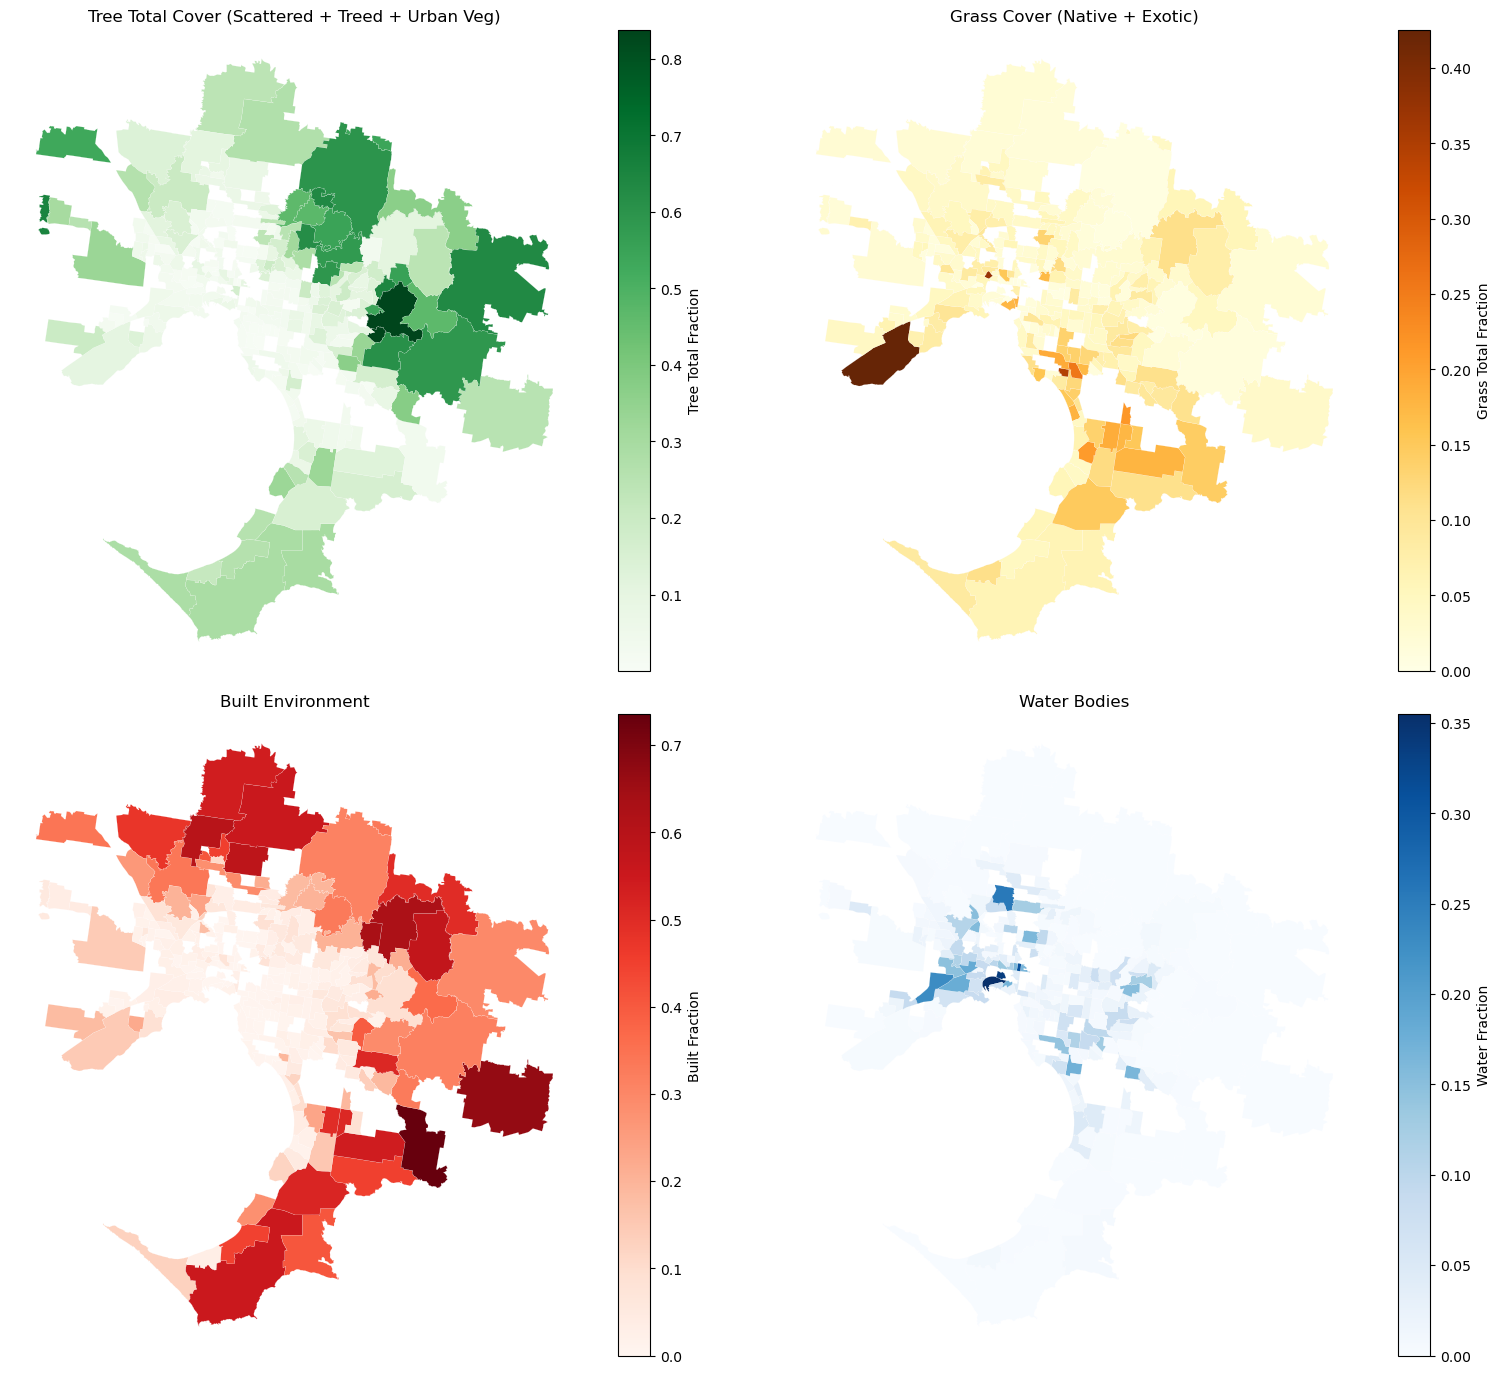

In [101]:
# Visualisation of land cover fractions

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Total tree fraction
q2_projected.plot(
    column="tree_total_frac",
    cmap="Greens",
    legend=True,
    legend_kwds={"label": "Tree Total Fraction"},
    edgecolor="white",
    linewidth=0.1,
    ax=axes[0]
)
axes[0].set_title("Tree Total Cover (Scattered + Treed + Urban Veg)", fontsize=12)
axes[0].axis("off")

# Total grass fraction
q2_projected.plot(
    column="grass_total_frac",
    cmap="YlOrBr",
    legend=True,
    legend_kwds={"label": "Grass Total Fraction"},
    edgecolor="white",
    linewidth=0.1,
    ax=axes[1]
)
axes[1].set_title("Grass Cover (Native + Exotic)", fontsize=12)
axes[1].axis("off")

# Built environment fraction
q2_projected.plot(
    column="built_frac",
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "Built Fraction"},
    edgecolor="white",
    linewidth=0.1,
    ax=axes[2]
)
axes[2].set_title("Built Environment", fontsize=12)
axes[2].axis("off")

# Water fraction
q2_projected.plot(
    column="water_frac",
    cmap="Blues",
    legend=True,
    legend_kwds={"label": "Water Fraction"},
    edgecolor="white",
    linewidth=0.1,
    ax=axes[3]
)
axes[3].set_title("Water Bodies", fontsize=12)
axes[3].axis("off")

plt.tight_layout()

plt.savefig(
    map_dir / "landcover_4maps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

These four spatial pattern maps reveal the geological environment of the Greater Melbourne area: High built environment values ​​are extremely concentrated in the city center, north and southeast of Melbourne, while tree cover is lower in these areas, which also have a stronger heat island effect.

### 6.5 Geographically Weighted Regression (GWR) Model

In [105]:
# Geographically Weighted Regression (GWR) Model

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
import os

from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

warnings.filterwarnings("ignore")

# 1. Prepare data for GWR
# Reproject to a projected CRS suitable for Melbourne distance calculation
q2_gwr = q2.to_crs(epsg=7855).copy()

# Keep only required columns and remove missing values
gwr_data = q2_gwr[
    [
        "coverage",
        "tree_density",
        "UHI18_M",
        "geometry"
    ]
].dropna().copy()

print("Number of observations used in GWR:", len(gwr_data))

# Get centroid coordinates
centroids = gwr_data.geometry.centroid
coords = np.column_stack((centroids.x, centroids.y))

# Dependent variable: Urban Heat Island intensity
y = gwr_data["UHI18_M"].values.reshape((-1, 1))

# Independent variables: open space coverage and tree density
X_variables = gwr_data[
    [
        "coverage",
        "tree_density"
    ]
].values

# 2. Bandwidth selection

bw_selector = Sel_BW(
    coords,
    y,
    X_variables,
    kernel="gaussian",
    fixed=False
)

best_bw = bw_selector.search(criterion="AICc")

print("Best bandwidth:", best_bw)

# 3. Fit GWR model

gwr_model = GWR(
    coords,
    y,
    X_variables,
    bw=best_bw,
    kernel="gaussian",
    fixed=False
)

gwr_results = gwr_model.fit()

# Print model summary
gwr_results.summary()

Number of observations used in GWR: 257
Best bandwidth: 47.0
Model type                                                         Gaussian
Number of observations:                                                 257
Number of covariates:                                                     3

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            854.019
Log-likelihood:                                                    -518.980
AIC:                                                               1043.960
AICc:                                                              1046.119
BIC:                                                               -555.446
R2:                                                                   0.002
Adj. R2:                                                             -0.006

Variable                              Est.         SE  t(Est/SE)    p-value

In [108]:
# Add GWR local coefficients to GeoDataFrame for mapping

gwr_output = gwr_data.copy()

gwr_output["gwr_intercept"] = gwr_results.params[:, 0]
gwr_output["gwr_coverage_coef"] = gwr_results.params[:, 1]
gwr_output["gwr_tree_density_coef"] = gwr_results.params[:, 2]
gwr_output["gwr_local_r2"] = gwr_results.localR2

gwr_output[
    [
        "coverage",
        "tree_density",
        "UHI18_M",
        "gwr_coverage_coef",
        "gwr_tree_density_coef",
        "gwr_local_r2"
    ]
].head()

,coverage,tree_density,UHI18_M,gwr_coverage_coef,gwr_tree_density_coef,gwr_local_r2
0,11.790865,3050.020758,8.385504,-0.022109,-0.000430,0.389830
1,61.657575,456.849792,6.900058,-0.017769,-0.000317,0.377953
2,21.359952,3108.183493,7.630220,-0.020720,-0.000401,0.390374
3,42.719471,411.225408,8.069294,-0.016938,-0.000311,0.382648
4,30.647845,734.992220,3.073223,-0.004554,0.000069,0.286816


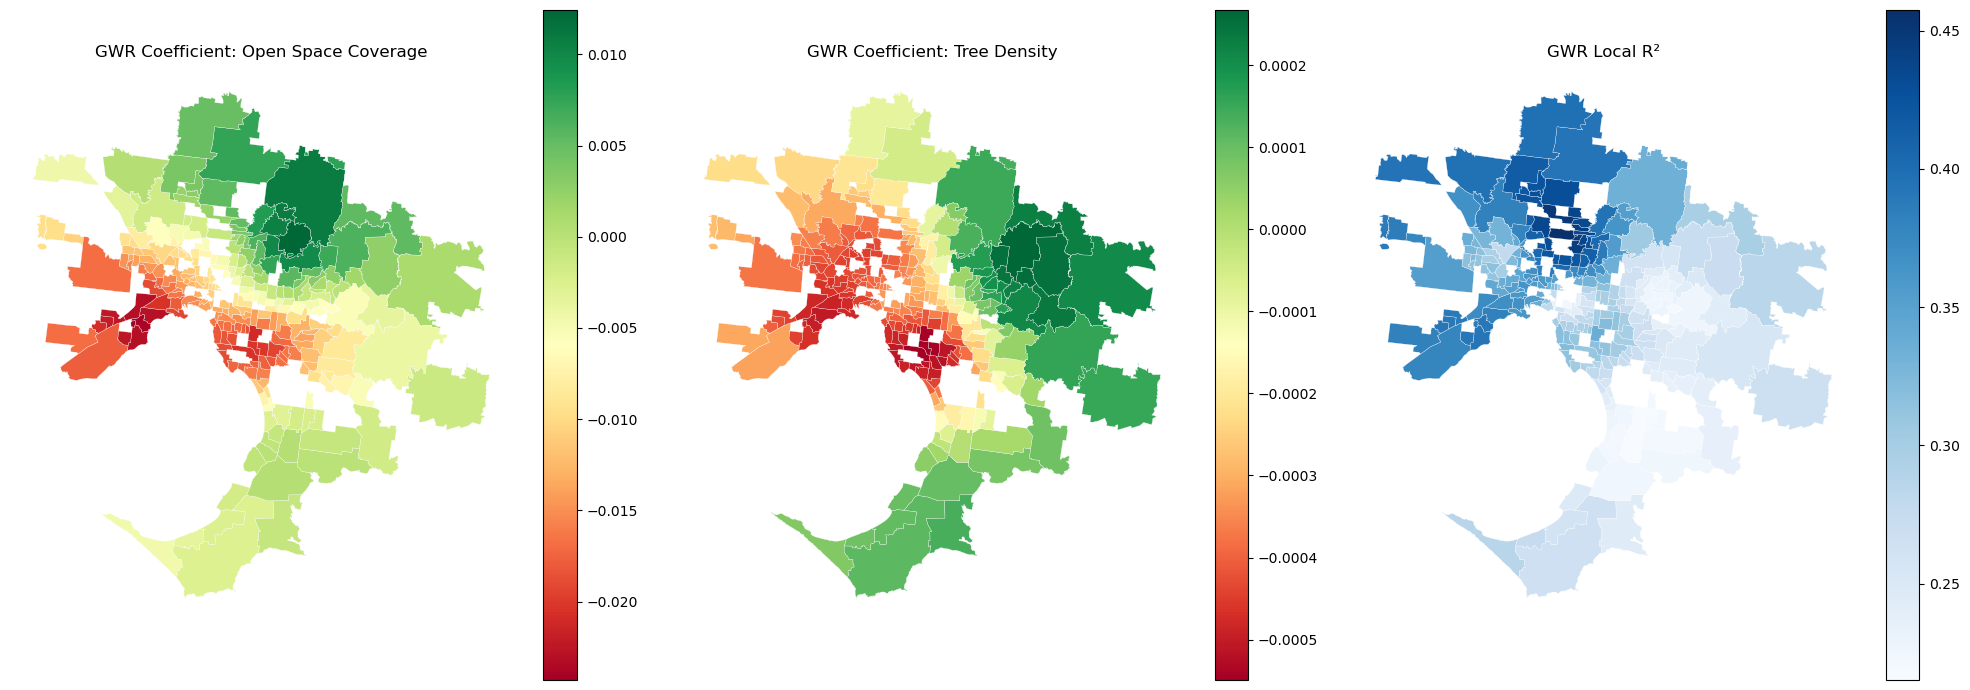

In [109]:
# Map GWR local coefficients and local R2

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

gwr_output.plot(
    column="gwr_coverage_coef",
    cmap="RdYlGn",
    legend=True,
    ax=axes[0],
    edgecolor="white",
    linewidth=0.2
)
axes[0].set_title("GWR Coefficient: Open Space Coverage", fontsize=12)
axes[0].axis("off")

gwr_output.plot(
    column="gwr_tree_density_coef",
    cmap="RdYlGn",
    legend=True,
    ax=axes[1],
    edgecolor="white",
    linewidth=0.2
)
axes[1].set_title("GWR Coefficient: Tree Density", fontsize=12)
axes[1].axis("off")

gwr_output.plot(
    column="gwr_local_r2",
    cmap="Blues",
    legend=True,
    ax=axes[2],
    edgecolor="white",
    linewidth=0.2
)
axes[2].set_title("GWR Local R²", fontsize=12)
axes[2].axis("off")

plt.tight_layout()

plt.savefig(
    map_dir / "gwr_results_maps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 6.5.1 OLS Results

The ordinary least squares (OLS) linear regression model to empirically test the linear hypothesis of $$UHI = \beta_0 + \beta_1 \cdot \text{Open Space Coverage} + \beta_2 \cdot \text{Tree Density}$$ across SA2 spatial units in the Greater Melbourne area.

Based on the output, we can see that the $p$-values ​​for both independent variables are > 0.05 (open space coverage: $p$=0.824, tree density: $p$=0.512), therefore we fail to refuse the null hypothesis, indicating no significant linear relationship.

$R^2 ≈ $ 0.002, and after adjustment, $R^2$ < 0, suggesting that open space coverage and tree density have almost no global linear explanatory power for urban heat island intensity (UHI).

The OLS model concludes that increasing open space or tree density does not linearly reduce heat island intensity across the entire Melbourne region.

#### 6.5.2 GWR Model

The GWR model is specified as:

$$
\text{UHI}_i = \beta_0(u_i, v_i) + \beta_1(u_i, v_i) \cdot \text{Open Space Coverage}_i + \beta_2(u_i, v_i) \cdot \text{Tree Density}_i + \varepsilon_i
$$

where:

- $(u_i, v_i)$ are the spatial coordinates (e.g., projected easting and northing) of SA2 centroid $i$;
- $\beta_0(u_i, v_i)$ is the local intercept at location $i$;
- $\beta_1(u_i, v_i)$ and $\beta_2(u_i, v_i)$ are local coefficients for open space coverage and tree density, respectively;
- $\varepsilon_i$ is the random error term.

The local coefficients are estimated via weighted least squares using an adaptive Gaussian kernel, with bandwidth selected by minimizing the AICc criterion.

The GWR's $R^2$ = 0.325, adjusted $R^2$ = 0.299, is a significant improvement compared to the global model's 0.002. This indicates that incorporating spatial location into the model significantly enhances its explanatory power.

The AICc decreased from 1046 to 959.6, demonstrating that the GWR model's fit is far superior to ordinary linear regression.

The bandwidth of 47 neighbors indicates that each local regression uses approximately 47 neighboring SA2 regions for weighted fitting, suggesting a moderate scale of influence.

From the parameter statistics table, we can see:

* Intercept (X0): Mean is 9.32, range from 6.78 to 10.75, indicating significant differences in the basic heat island intensity across different regions.

* Open space coverage coefficient (X1): Mean is -0.008, range from -0.024 to 0.012, indicating that in most areas, cover has a slight negative impact on UHI, i.e., cooling, but in some areas it has a positive impact, i.e., anomalous warming. Significant spatial heterogeneity is observed.

* Tree density coefficient (X2): Mean close to 0, range from -0.001 to 0.000, indicating that the effect of tree density is very weak and inconsistent in direction.

#### 6.5.3 GWR Local $R^2$ Spatial Distribution

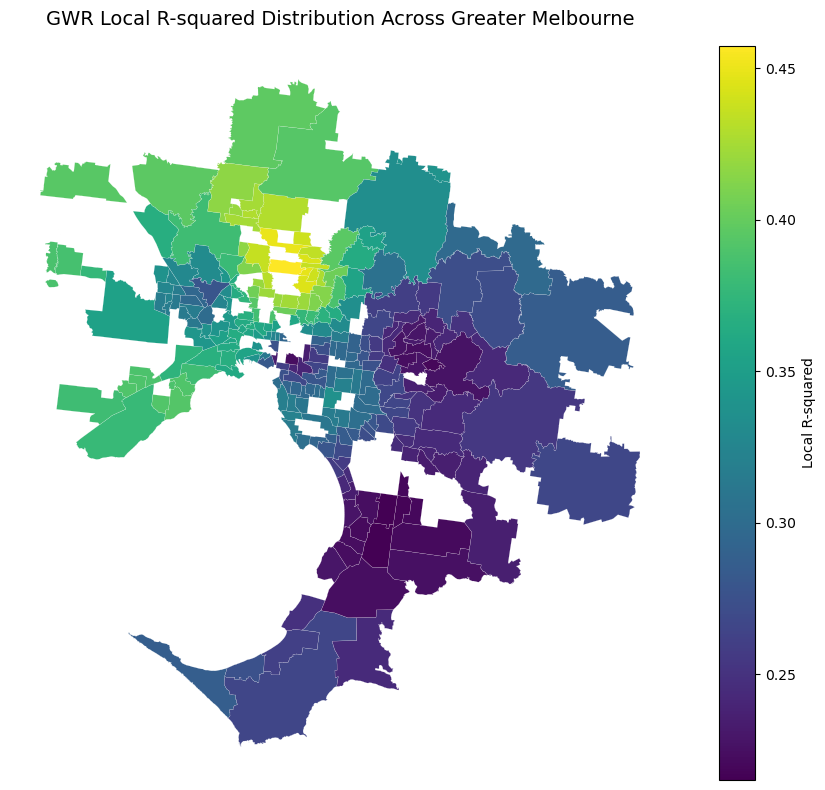

In [112]:
# GWR Local R-squared spatial distribution

fig, ax = plt.subplots(figsize=(10, 8))

gwr_output.plot(
    column="gwr_local_r2",
    cmap="viridis",
    legend=True,
    linewidth=0.1,
    edgecolor="white",
    legend_kwds={"label": "Local R-squared"},
    ax=ax
)

ax.set_title(
    "GWR Local R-squared Distribution Across Greater Melbourne",
    fontsize=14,
    pad=15
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    map_dir / "gwr_local_r2_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

This local $R^2$ spatial distribution map confirms the strong spatial nonstationarity of the greening index's effect on mitigating the urban heat island effect (UHI). The model's explanatory power increases from a very low value in the southeast coastal area ($R^2$ around 0.23) towards the northwest, peaking in Melbourne's northwest suburbs and northern edge ($R^2$ > 0.45). This clear gradient pattern indicates that in the northwest region, far from the influence of oceanic air currents, tree density and green cover affect surface temperature, and the model can explain nearly half of the local heat island intensity variation. Conversely, in the southern and eastern coastal areas, the independent explanatory power of the greening index is reduced due to complex coastal climates (such as sea breeze modulation).

#### 6.5.4 Visualising Spatial Heterogeneity through GWR

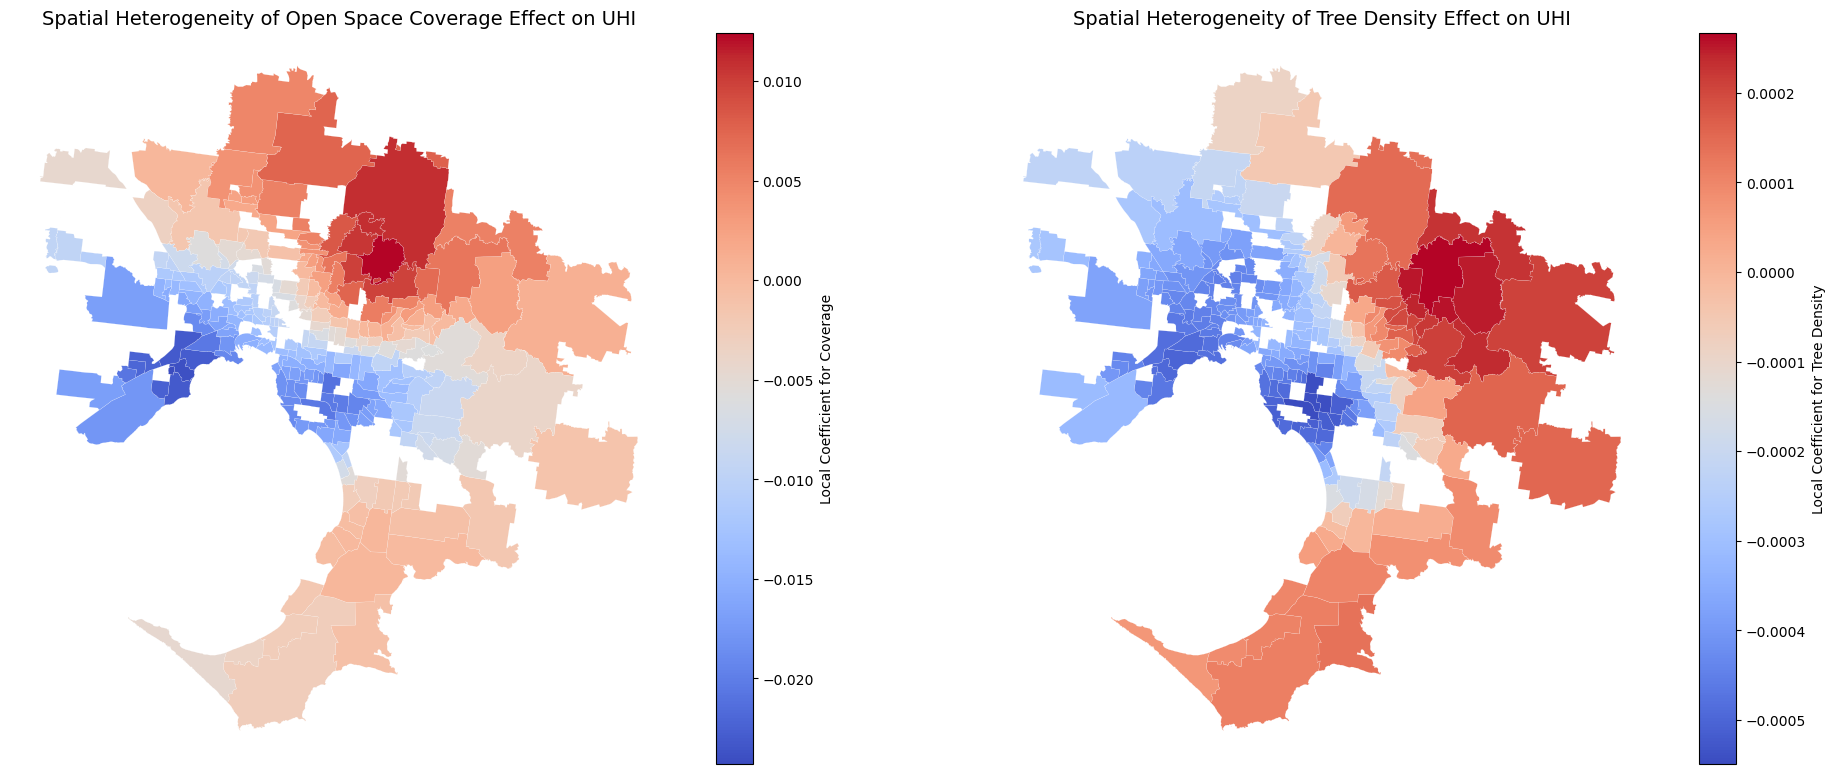

In [113]:

# Make sure GWR coefficients are attached to a GeoDataFrame
gwr_output = gwr_data.copy()

gwr_output["gwr_coef_intercept"] = gwr_results.params[:, 0]
gwr_output["gwr_coef_coverage"] = gwr_results.params[:, 1]
gwr_output["gwr_coef_tree_density"] = gwr_results.params[:, 2]
gwr_output["gwr_local_R2"] = gwr_results.localR2

# Plot local coefficients
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Open space coverage coefficient
gwr_output.plot(
    column="gwr_coef_coverage",
    cmap="coolwarm",
    legend=True,
    linewidth=0.1,
    edgecolor="white",
    ax=axes[0],
    legend_kwds={"label": "Local Coefficient for Coverage"}
)

axes[0].set_title(
    "Spatial Heterogeneity of Open Space Coverage Effect on UHI",
    fontsize=14
)
axes[0].axis("off")

# Tree density coefficient
gwr_output.plot(
    column="gwr_coef_tree_density",
    cmap="coolwarm",
    legend=True,
    linewidth=0.1,
    edgecolor="white",
    ax=axes[1],
    legend_kwds={"label": "Local Coefficient for Tree Density"}
)

axes[1].set_title(
    "Spatial Heterogeneity of Tree Density Effect on UHI",
    fontsize=14
)
axes[1].axis("off")

plt.tight_layout()

plt.savefig(
    map_dir / "gwr_local_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

* Spatial Heterogeneity of Open Space Coverage Effect on UHI

The impact of open space coverage on UHI exhibits a south-north spatial divide.

Positive values ​​in these localised areas mean that the higher the open space coverage, the higher the urban heat island intensity (UHI). This contradicts the conventional understanding that open spaces typically have a cooling effect. Possible reasons include the possibility that these open spaces might be bare soil, dry grass, or sports fields.

Negative values ​​indicate a consistent cooling effect: increased cover reduces the UHI, as seen in Melbourne's CBD and southwest coastal areas, suggesting that the construction of open green spaces in these regions yields significant cooling returns.

The coexistence of positive and negative coefficients indicates that the effect of open spaces is not unidirectional, but heavily dependent on local vegetation type, soil moisture, surrounding building density, and wind conditions.

* Spatial Heterogeneity of Tree Density Effect on UHI

The impact of tree density on UHI exhibits a clear east-west spatial divide.

Most areas show negative values, indicating that higher tree density corresponds to lower UHI—a consistent cooling effect. The dark blue areas are highly concentrated in Melbourne's west and the inner west. In the older eastern suburbs, possibly because the existing urban forests are already close to saturation, further increases in tree density have reduced their moderating effect on overall temperature.

Compared to open spaces, the coefficient for tree density is more stable in sign, almost entirely negative, indicating that the shading effect of trees dominates in most areas of Melbourne, and the cooling mechanism is stable.

### 6.6 Conclusion and Limitation

This section investigates the impact of open space coverage and tree density on the intensity of the urban heat island in the Melbourne metropolitan area. Traditional statistical methods did not reveal a significant global linear relationship, and spatial cluster analysis also indicated that the heat island effect is mainly driven by regional-scale processes. However, geographically weighted regression (GWR) further reveals that tree density exhibits a stable cooling effect across almost the entire study area (with consistently negative local coefficients), while the impact of open space coverage shows strong spatial heterogeneity: it can cool in some areas but may exacerbate the heat island effect in others.This suggests that the cooling effect of green infrastructure cannot be generalized. Tree density is a more reliable factor in mitigating the heat island, while the effect of open space depends on its specific type, humidity conditions, and surrounding environment. Therefore, heat island mitigation strategies in Melbourne should prioritize increasing tree density and involve specific analysis and design of open spaces.

**Limitations:**

1. The analysis was conducted at the SA2 level, which may have masked significant differences within suburban areas. When data is aggregated to relatively large spatial units, the localized cooling effects of parks and street trees may not be fully captured.

2. Open space coverage and tree density were used as a simplified indicator of the quality of green infrastructure. This dataset does not distinguish between different vegetation types, canopy density, tree height, irrigation conditions, or accessibility, all of which can influence cooling effects.

3. Residual analysis strongly suggests that future research should incorporate more environmental and urban variables, such as building density, industrial land, elevation, and distance from the coast.

## 7. Social Vulnerability Analysis

This section uses ABS Census data to measure social vulnerability at the SA2 level. The indicators include median household income, elderly population percentage, children population percentage and population density. This part is later used as one input for the final priority intervention index.

### 7.1 Prepare data

In [121]:
# Load existing SA2 master base dataset
sa2_master = gpd.read_file(processed_dir / "sa2_master_base.gpkg")

# Add official SA2 area information to the existing SA2 master dataset
sa2_master = sa2_master.copy()

sa2_master["sa2_code"] = sa2_master["sa2_code"].astype(str)

sa2_area_info = sa2_analysis.copy()

if "SA2_CODE_2021" in sa2_area_info.columns:
    sa2_area_info = sa2_area_info.rename(columns={
        "SA2_CODE_2021": "sa2_code"
    })

sa2_area_info["sa2_code"] = sa2_area_info["sa2_code"].astype(str)

if "AREA_ALBERS_SQKM" in sa2_area_info.columns and "area_km2_official" not in sa2_master.columns:
    sa2_area_info = sa2_area_info[["sa2_code", "AREA_ALBERS_SQKM"]].copy()
    sa2_area_info = sa2_area_info.rename(columns={
        "AREA_ALBERS_SQKM": "area_km2_official"
    })

    sa2_master = sa2_master.merge(
        sa2_area_info,
        on="sa2_code",
        how="left"
    )

sa2_master["area_m2_geom_check"] = sa2_master.geometry.area
sa2_master["area_km2_geom_check"] = sa2_master["area_m2_geom_check"] / 1_000_000

sa2_master.to_file(
    processed_dir / "sa2_master_base.gpkg",
    layer="sa2_master_base",
    driver="GPKG"
)

print("SA2 master base updated successfully.")
print("Number of SA2 areas:", len(sa2_master))

sa2_master.head()

SA2 master base updated successfully.
Number of SA2 areas: 360


,sa2_code,sa2_name,area_m2,area_km2,area_km2_official,area_m2_geom_check,area_km2_geom_check,geometry
0,213051362,Hoppers Crossing - South,7.012411e+06,7.012411,7.0114,7.012411e+06,7.012411,"MULTIPOLYGON (((294653.085 5806028.552, 294645..."
1,213051368,Werribee - South,1.140616e+08,114.061560,114.0332,1.140616e+08,114.061560,"MULTIPOLYGON (((300955.332 5798020.917, 300955..."
2,213051467,Werribee - East,7.758551e+06,7.758551,7.7569,7.758551e+06,7.758551,"MULTIPOLYGON (((292554.398 5804662.406, 292548..."
3,213051468,Werribee - West,5.991604e+07,59.916045,127.6631,5.991604e+07,59.916045,"MULTIPOLYGON (((288867.598 5797885.557, 288870..."
4,213051579,Manor Lakes - Quandong,1.493557e+07,14.935574,72.0339,1.493557e+07,14.935574,"MULTIPOLYGON (((281564.588 5805244.323, 284521..."


In [122]:
# Load Census tables

# Read G01 and G02 Census tables
g01 = pd.read_csv(census_dir / "2021Census_G01_VIC_SA2.csv")
g02 = pd.read_csv(census_dir / "2021Census_G02_VIC_SA2.csv")

print("G01 shape:", g01.shape)
print("G02 shape:", g02.shape)

g01.head()

G01 shape: (524, 109)
G02 shape: (524, 9)


,SA2_CODE_2021,Tot_P_M,Tot_P_F,Tot_P_P,Age_0_4_yr_M,Age_0_4_yr_F,Age_0_4_yr_P,Age_5_14_yr_M,Age_5_14_yr_F,Age_5_14_yr_P,...,High_yr_schl_comp_Yr_8_belw_P,High_yr_schl_comp_D_n_g_sch_M,High_yr_schl_comp_D_n_g_sch_F,High_yr_schl_comp_D_n_g_sch_P,Count_psns_occ_priv_dwgs_M,Count_psns_occ_priv_dwgs_F,Count_psns_occ_priv_dwgs_P,Count_Persons_other_dwgs_M,Count_Persons_other_dwgs_F,Count_Persons_other_dwgs_P
0,201011001,8188,8648,16835,623,585,1213,1453,1364,2815,...,430,23,22,45,7786,8263,16055,268,313,585
1,201011002,5711,6420,12131,267,224,490,658,630,1290,...,355,10,13,22,5152,5811,10969,755,766,1521
2,201011005,3594,3664,7261,190,172,357,561,587,1148,...,169,10,8,14,3308,3417,6722,217,215,435
3,201011006,5111,5553,10661,382,426,804,784,683,1464,...,408,22,13,39,4837,5211,10052,227,270,501
4,201011007,2172,2055,4230,125,99,223,338,326,668,...,126,4,3,8,2099,2013,4107,37,37,71


In [123]:
# Prepare age and population indicators

g01_clean = g01.copy()

# Standardise SA2 code
g01_clean["sa2_code"] = g01_clean["SA2_CODE_2021"].astype(str)

# Convert required columns to numeric
age_cols = [
    "Age_0_4_yr_P",
    "Age_5_14_yr_P",
    "Age_65_74_yr_P",
    "Age_75_84_yr_P",
    "Age_85ov_P",
    "Tot_P_P"
]

for col in age_cols:
    g01_clean[col] = pd.to_numeric(g01_clean[col], errors="coerce")

# Calculate children population: age 0 to 14
g01_clean["children_pop"] = (
    g01_clean["Age_0_4_yr_P"] +
    g01_clean["Age_5_14_yr_P"]
)

# Calculate elderly population: age 65 and over
g01_clean["elderly_pop"] = (
    g01_clean["Age_65_74_yr_P"] +
    g01_clean["Age_75_84_yr_P"] +
    g01_clean["Age_85ov_P"]
)

# Total population
g01_clean["total_population"] = g01_clean["Tot_P_P"]

# Calculate percentage indicators
g01_clean["children_pct"] = (
    g01_clean["children_pop"] / g01_clean["total_population"] * 100
)

g01_clean["elderly_pct"] = (
    g01_clean["elderly_pop"] / g01_clean["total_population"] * 100
)

# Keep useful columns
g01_clean = g01_clean[
    [
        "sa2_code",
        "children_pop",
        "elderly_pop",
        "total_population",
        "children_pct",
        "elderly_pct"
    ]
].copy()

g01_clean.head()

,sa2_code,children_pop,elderly_pop,total_population,children_pct,elderly_pct
0,201011001,4028,2178,16835,23.926344,12.937333
1,201011002,1780,2826,12131,14.673151,23.295689
2,201011005,1505,1334,7261,20.727173,18.372125
3,201011006,2268,1578,10661,21.273802,14.801613
4,201011007,891,608,4230,21.063830,14.373522


In [119]:
# Prepare median weekly household income indicator

g02_clean = g02.copy()

# Standardise SA2 code
g02_clean["sa2_code"] = g02_clean["SA2_CODE_2021"].astype(str)

# Use median weekly household income
g02_clean["median_income"] = pd.to_numeric(
    g02_clean["Median_tot_hhd_inc_weekly"],
    errors="coerce"
)

# Keep useful columns
g02_clean = g02_clean[
    [
        "sa2_code",
        "median_income"
    ]
].copy()

g02_clean.head()

,sa2_code,median_income
0,201011001,1952
1,201011002,1573
2,201011005,1927
3,201011006,1627
4,201011007,2065


In [124]:
# Merge age/population table with income table

census_clean = g01_clean.merge(
    g02_clean,
    on="sa2_code",
    how="left"
)

# Remove rows with missing values in selected indicators
census_clean = census_clean.dropna(
    subset=[
        "children_pct",
        "elderly_pct",
        "total_population",
        "median_income"
    ]
).copy()

print("Clean Census indicator table:", census_clean.shape)

census_clean.head()

Clean Census indicator table: (520, 7)


,sa2_code,children_pop,elderly_pop,total_population,children_pct,elderly_pct,median_income
0,201011001,4028,2178,16835,23.926344,12.937333,1952
1,201011002,1780,2826,12131,14.673151,23.295689,1573
2,201011005,1505,1334,7261,20.727173,18.372125,1927
3,201011006,2268,1578,10661,21.273802,14.801613,1627
4,201011007,891,608,4230,21.063830,14.373522,2065


In [126]:
# Load cleaned SA2 boundary for social vulnerability analysis

sa2_melb = gpd.read_file(processed_dir / "sa2_melbourne_clean.gpkg")

# Make sure CRS is correct
TARGET_CRS = "EPSG:7855"
sa2_melb = sa2_melb.to_crs(TARGET_CRS)

# Make sure column names are consistent
if "SA2_CODE_2021" in sa2_melb.columns:
    sa2_melb = sa2_melb.rename(columns={
        "SA2_CODE_2021": "sa2_code",
        "SA2_NAME_2021": "sa2_name"
    })

# Make sure SA2 code is string
sa2_melb["sa2_code"] = sa2_melb["sa2_code"].astype(str)

print("SA2 boundary loaded successfully.")
print("Number of SA2 areas:", len(sa2_melb))

sa2_melb.head()

SA2 boundary loaded successfully.
Number of SA2 areas: 360


,id,sa2_code,sa2_name,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,GCCSA_NAME_2021,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,area_km2,geometry
0,1081,213051362,Hoppers Crossing - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.0114,http://linked.data.gov.au/dataset/asgsed3/SA2/...,7.0114,"MULTIPOLYGON (((294653.085 5806028.552, 294645..."
1,1083,213051368,Werribee - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,114.0332,http://linked.data.gov.au/dataset/asgsed3/SA2/...,114.0332,"MULTIPOLYGON (((300955.332 5798020.917, 300955..."
2,1086,213051467,Werribee - East,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.7569,http://linked.data.gov.au/dataset/asgsed3/SA2/...,7.7569,"MULTIPOLYGON (((292554.398 5804662.406, 292548..."
3,1087,213051468,Werribee - West,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,127.6631,http://linked.data.gov.au/dataset/asgsed3/SA2/...,127.6631,"MULTIPOLYGON (((288867.598 5797885.557, 288870..."
4,1088,213051579,Manor Lakes - Quandong,1,New,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,72.0339,http://linked.data.gov.au/dataset/asgsed3/SA2/...,72.0339,"MULTIPOLYGON (((281564.588 5805244.323, 284521..."


In [127]:
# Join Census indicators to SA2 boundary

# Make sure SA2 code is string before joining
sa2_melb["sa2_code"] = sa2_melb["sa2_code"].astype(str)
census_clean["sa2_code"] = census_clean["sa2_code"].astype(str)

# Merge census indicators with SA2 boundary
sa2_census = sa2_melb.merge(
    census_clean,
    on="sa2_code",
    how="left"
)

# Calculate population density
# Use official SA2 area if available
if "area_km2" in sa2_census.columns:
    sa2_census["population_density"] = (
        sa2_census["total_population"] / sa2_census["area_km2"]
    )
elif "AREA_ALBERS_SQKM" in sa2_census.columns:
    sa2_census["population_density"] = (
        sa2_census["total_population"] / sa2_census["AREA_ALBERS_SQKM"]
    )
else:
    sa2_census["area_km2_temp"] = sa2_census.geometry.area / 1_000_000
    sa2_census["population_density"] = (
        sa2_census["total_population"] / sa2_census["area_km2_temp"]
    )

# Preview selected indicators
sa2_census[
    [
        "sa2_code",
        "sa2_name",
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density"
    ]
].head()

,sa2_code,sa2_name,median_income,children_pct,elderly_pct,population_density
0,213051362,Hoppers Crossing - South,1470.0,19.470488,15.619007,2677.354023
1,213051368,Werribee - South,1802.0,18.887567,15.425342,147.413209
2,213051467,Werribee - East,1374.0,19.495003,15.228827,2450.721293
3,213051468,Werribee - West,1995.0,23.123405,8.030079,174.999667
4,213051579,Manor Lakes - Quandong,2309.0,30.519970,3.570083,147.375055


In [128]:
# Check missing values after joining

sa2_census[
    [
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density"
    ]
].isna().sum()

median_income         2
children_pct          2
elderly_pct           2
population_density    2
dtype: int64

In [129]:
# Check which SA2s have missing census data

missing_census = sa2_census[
    sa2_census["median_income"].isna()
][
    [
        "sa2_code",
        "sa2_name",
        "area_km2"
    ]
]

missing_census

,sa2_code,sa2_name,area_km2
88,206041127,West Melbourne - Industrial,6.1992
187,206041507,Royal Botanic Gardens Victoria,1.3511


In [130]:
# Remove SA2s with missing census indicators

sa2_census = sa2_census.dropna(
    subset=[
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density"
    ]
).copy()

# Check number of SA2s after removing missing rows
print("Number of SA2s after removing missing census rows:", len(sa2_census))

# Check missing values again
sa2_census[
    [
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density"
    ]
].isna().sum()

Number of SA2s after removing missing census rows: 358


median_income         0
children_pct          0
elderly_pct           0
population_density    0
dtype: int64

### 7.2 Calculate social vulnerability score

In [133]:
# Function for min-max standardisation
def standardise(column):
    if column.max() == column.min():
        return column * 0
    return (column - column.min()) / (column.max() - column.min())

# Function for reverse min-max standardisation
# Used for income because lower income means higher vulnerability
def reverse_standardise(column):
    if column.max() == column.min():
        return column * 0
    return (column.max() - column) / (column.max() - column.min())


# Calculate vulnerability component scores
sa2_census["income_score"] = reverse_standardise(sa2_census["median_income"])
sa2_census["elderly_score"] = standardise(sa2_census["elderly_pct"])
sa2_census["children_score"] = standardise(sa2_census["children_pct"])
sa2_census["density_score"] = standardise(sa2_census["population_density"])

# Calculate final social vulnerability score
sa2_census["social_vulnerability_score"] = (
    sa2_census["income_score"] +
    sa2_census["elderly_score"] +
    sa2_census["children_score"] +
    sa2_census["density_score"]
) / 4

# Create top 10 table as a variable for reporting
top_social = sa2_census.sort_values(
    by="social_vulnerability_score",
    ascending=False
).head(10)

top_social_table = top_social[
    [
        "sa2_name",
        "median_income",
        "elderly_pct",
        "children_pct",
        "population_density",
        "social_vulnerability_score"
    ]
].copy()

top_social_table

,sa2_name,median_income,elderly_pct,children_pct,population_density,social_vulnerability_score
162,Rosebud - McCrae,1155.0,33.372559,14.029812,964.207819,0.483843
185,Mornington - West,1389.0,38.701446,10.802382,1652.145400,0.478759
11,Point Nepean,1430.0,32.239665,13.871082,294.860956,0.446123
20,Melton,1061.0,20.213036,18.792797,799.683615,0.442658
196,Melbourne CBD - North,1089.0,1.920569,2.744517,30039.173789,0.440371
184,Mornington - East,1502.0,26.003295,17.930807,1033.128183,0.437451
163,Dromana,1398.0,30.734700,13.444561,296.643178,0.435837
59,Campbellfield - Coolaroo,1104.0,15.638039,21.679018,882.897942,0.432606
140,Avondale Heights,1587.0,26.727478,15.975137,2290.384011,0.430057
68,Kings Park (Vic.),1246.0,17.571337,18.665522,3154.795479,0.428332


In [134]:
# Keep useful variables for later analysis

social_vulnerability_sa2 = sa2_census.copy()

social_vulnerability_indicators = sa2_census[
    [
        "sa2_code",
        "sa2_name",
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density",
        "income_score",
        "elderly_score",
        "children_score",
        "density_score",
        "social_vulnerability_score",
        "geometry"
    ]
].copy()

print("Social vulnerability variables are ready.")
print("Number of SA2 areas:", len(social_vulnerability_sa2))

Social vulnerability variables are ready.
Number of SA2 areas: 358


### 7.3 Map social vulnerability

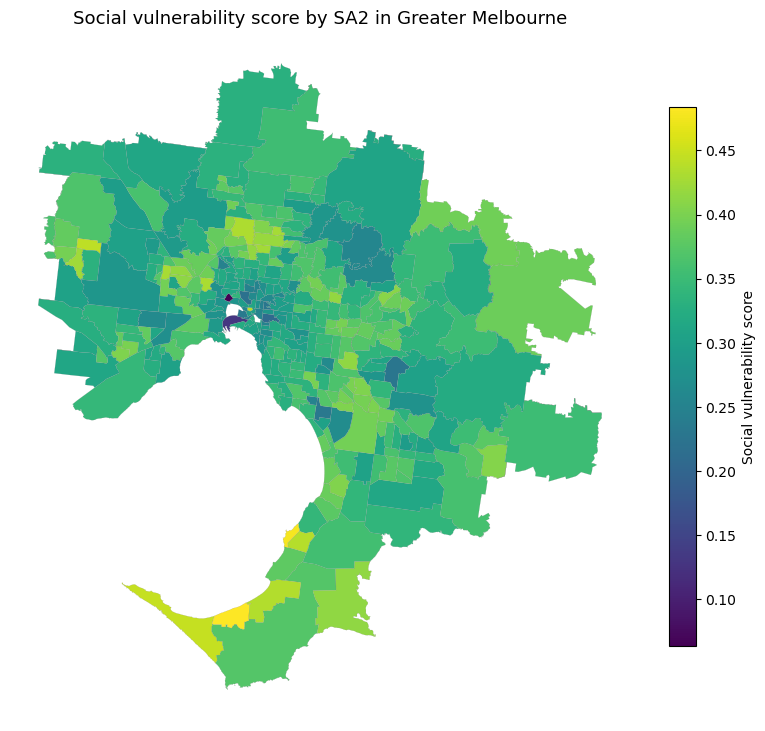

In [136]:
fig, ax = plt.subplots(figsize=(10, 10))

sa2_census.plot(
    column="social_vulnerability_score",
    legend=True,
    legend_kwds={
        "label": "Social vulnerability score",
        "shrink": 0.7
    },
    edgecolor="grey",
    linewidth=0.1,
    ax=ax
)

ax.set_title(
    "Social vulnerability score by SA2 in Greater Melbourne",
    fontsize=13
)

ax.axis("off")

plt.show()

### 7.4 Join social vulnerability with green space and urban heat

In [143]:
# Read Q2 green space and urban heat result
q2_result = gpd.read_file(processed_dir / "q2_green_heat.gpkg")

# Use social vulnerability result from previous section
social_vulnerability_sa2 = sa2_census.copy()

# Make sure SA2 codes are string
q2_result["sa2_code"] = (
    q2_result["sa2_code"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

social_vulnerability_sa2["sa2_code"] = (
    social_vulnerability_sa2["sa2_code"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

# Drop geometry from q2_result before joining
q2_attributes = q2_result.drop(
    columns=["geometry"],
    errors="ignore"
).copy()

# Use inner join because Q2 result only contains 257 SA2s
priority_result = social_vulnerability_sa2.merge(
    q2_attributes,
    on="sa2_code",
    how="inner"
)


priority_result[
    [
        "sa2_code",
        "sa2_name_x",
        "coverage",
        "open_area",
        "UHI18_M",
        "tree_density",
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density",
        "total_population",
        "social_vulnerability_score"
    ]
].head()

,sa2_code,sa2_name_x,coverage,open_area,UHI18_M,tree_density,median_income,children_pct,elderly_pct,population_density,total_population,social_vulnerability_score
0,213051362,Hoppers Crossing - South,11.790865,8.268239e+05,8.385504,3050.020758,1470.0,19.470488,15.619007,2677.354023,18772.0,0.398804
1,213051368,Werribee - South,61.657575,7.032759e+07,6.900058,456.849792,1802.0,18.887567,15.425342,147.413209,16810.0,0.343468
2,213051467,Werribee - East,21.359952,1.657223e+06,7.630220,3108.183493,1374.0,19.495003,15.228827,2450.721293,19010.0,0.402824
3,213051468,Werribee - West,42.719471,2.559582e+07,8.069294,411.225408,1995.0,23.123405,8.030079,174.999667,22341.0,0.312386
4,214021383,Point Nepean,30.647845,2.059349e+07,3.073223,734.992220,1430.0,13.871082,32.239665,294.860956,19811.0,0.446123


In [144]:
# Check missing values after joining

priority_result[
    [
        "coverage",
        "open_area",
        "UHI18_M",
        "tree_density",
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density",
        "total_population",
        "social_vulnerability_score"
    ]
].isna().sum()

coverage                      0
open_area                     0
UHI18_M                       0
tree_density                  0
median_income                 0
children_pct                  0
elderly_pct                   0
population_density            0
total_population              0
social_vulnerability_score    0
dtype: int64

In [141]:
# Check matching between social vulnerability result and Q2 result

print("Number of SA2s in social vulnerability:", len(social_vulnerability_sa2))
print("Number of SA2s in Q2 result:", len(q2_result))

print("Social vulnerability SA2 code type:", social_vulnerability_sa2["sa2_code"].dtype)
print("Q2 result SA2 code type:", q2_result["sa2_code"].dtype)

# Clean SA2 code format for checking
social_codes = social_vulnerability_sa2["sa2_code"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
q2_codes = q2_result["sa2_code"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True)

matched_codes = set(social_codes).intersection(set(q2_codes))

print("Matched SA2 codes:", len(matched_codes))
print("Missing Q2 result:", len(set(social_codes) - set(q2_codes)))

Number of SA2s in social vulnerability: 358
Number of SA2s in Q2 result: 257
Social vulnerability SA2 code type: object
Q2 result SA2 code type: object
Matched SA2 codes: 257
Missing Q2 result: 101


In [145]:
# Calculate green space area per person

priority_result["green_space_per_person"] = (
    priority_result["open_area"] / priority_result["total_population"]
)

priority_result[
    [
        "sa2_code",
        "sa2_name_x",
        "total_population",
        "coverage",
        "green_space_per_person"
    ]
].head()

,sa2_code,sa2_name_x,total_population,coverage,green_space_per_person
0,213051362,Hoppers Crossing - South,18772.0,11.790865,44.045596
1,213051368,Werribee - South,16810.0,61.657575,4183.675934
2,213051467,Werribee - East,19010.0,21.359952,87.176370
3,213051468,Werribee - West,22341.0,42.719471,1145.688078
4,214021383,Point Nepean,19811.0,30.647845,1039.497502


In [146]:
# Remove rows with missing values for final priority analysis

priority_result = priority_result.dropna(
    subset=[
        "coverage",
        "open_area",
        "UHI18_M",
        "green_space_per_person",
        "social_vulnerability_score"
    ]
).copy()

print("Number of SA2 areas used for priority analysis:", len(priority_result))

Number of SA2 areas used for priority analysis: 257


In [147]:
# Calculate priority intervention score

# Function for min-max standardisation
def standardise(column):
    if column.max() == column.min():
        return column * 0
    return (column - column.min()) / (column.max() - column.min())

# Function for reverse min-max standardisation
def reverse_standardise(column):
    if column.max() == column.min():
        return column * 0
    return (column.max() - column) / (column.max() - column.min())


# Higher urban heat means higher priority
priority_result["heat_score"] = standardise(priority_result["UHI18_M"])

# Lower green space coverage means higher priority
priority_result["low_coverage_score"] = reverse_standardise(priority_result["coverage"])

# Lower green space per person means higher priority
priority_result["low_green_per_person_score"] = reverse_standardise(
    priority_result["green_space_per_person"]
)

# Higher social vulnerability means higher priority
priority_result["social_score"] = standardise(
    priority_result["social_vulnerability_score"]
)

# Final priority intervention score
priority_result["priority_score"] = (
    priority_result["heat_score"] +
    priority_result["low_coverage_score"] +
    priority_result["low_green_per_person_score"] +
    priority_result["social_score"]
) / 4

priority_result[
    [
        "sa2_name_x",
        "heat_score",
        "low_coverage_score",
        "low_green_per_person_score",
        "social_score",
        "priority_score"
    ]
].head()

,sa2_name_x,heat_score,low_coverage_score,low_green_per_person_score,social_score,priority_score
0,Hoppers Crossing - South,0.715014,0.840835,0.999674,0.797695,0.838305
1,Werribee - South,0.587907,0.167683,0.969047,0.666054,0.597673
2,Werribee - East,0.650386,0.711662,0.999355,0.807260,0.792165
3,Werribee - West,0.687956,0.423329,0.991524,0.592111,0.673730
4,Point Nepean,0.260452,0.586284,0.992309,0.910267,0.687328


In [148]:
# Calculate priority intervention score

# Function for min-max standardisation
def standardise(column):
    if column.max() == column.min():
        return column * 0
    return (column - column.min()) / (column.max() - column.min())

# Function for reverse min-max standardisation
def reverse_standardise(column):
    if column.max() == column.min():
        return column * 0
    return (column.max() - column) / (column.max() - column.min())


# Higher urban heat means higher priority
priority_result["heat_score"] = standardise(priority_result["UHI18_M"])

# Lower green space coverage means higher priority
priority_result["low_coverage_score"] = reverse_standardise(priority_result["coverage"])

# Lower green space per person means higher priority
priority_result["low_green_per_person_score"] = reverse_standardise(
    priority_result["green_space_per_person"]
)

# Higher social vulnerability means higher priority
priority_result["social_score"] = standardise(
    priority_result["social_vulnerability_score"]
)

# Final priority intervention score
priority_result["priority_score"] = (
    priority_result["heat_score"] +
    priority_result["low_coverage_score"] +
    priority_result["low_green_per_person_score"] +
    priority_result["social_score"]
) / 4

priority_result[
    [
        "sa2_name_x",
        "heat_score",
        "low_coverage_score",
        "low_green_per_person_score",
        "social_score",
        "priority_score"
    ]
].head()

,sa2_name_x,heat_score,low_coverage_score,low_green_per_person_score,social_score,priority_score
0,Hoppers Crossing - South,0.715014,0.840835,0.999674,0.797695,0.838305
1,Werribee - South,0.587907,0.167683,0.969047,0.666054,0.597673
2,Werribee - East,0.650386,0.711662,0.999355,0.807260,0.792165
3,Werribee - West,0.687956,0.423329,0.991524,0.592111,0.673730
4,Point Nepean,0.260452,0.586284,0.992309,0.910267,0.687328


In [149]:
# Show top 10 SA2s with the highest priority intervention score

top_priority = priority_result.sort_values(
    by="priority_score",
    ascending=False
).head(10)

top_priority_table = top_priority[
    [
        "sa2_name_x",
        "UHI18_M",
        "coverage",
        "green_space_per_person",
        "social_vulnerability_score",
        "priority_score"
    ]
].copy()

top_priority_table

,sa2_name_x,UHI18_M,coverage,green_space_per_person,social_vulnerability_score,priority_score
101,St Albans - North,10.610981,5.891464,18.672790,0.415288,0.915672
8,Melton,10.901197,15.500625,193.895584,0.442658,0.905405
111,Burnside,11.348166,7.605777,33.472262,0.372398,0.900121
39,Kings Park (Vic.),10.967239,16.103500,51.048446,0.428332,0.896528
37,Delahey,11.409298,8.771380,38.074284,0.366621,0.894051
7,Melton West,11.451552,13.209407,150.797118,0.382278,0.889081
23,Tullamarine,9.889888,5.812658,34.117733,0.391998,0.886632
6,Bacchus Marsh,9.601099,0.025371,0.128794,0.362938,0.882765
249,Noble Park - West,9.471841,5.862634,14.343045,0.396210,0.880062
105,Sunshine West,10.234022,9.697581,67.777624,0.387965,0.878422


### 7.5 Map priority intervention score

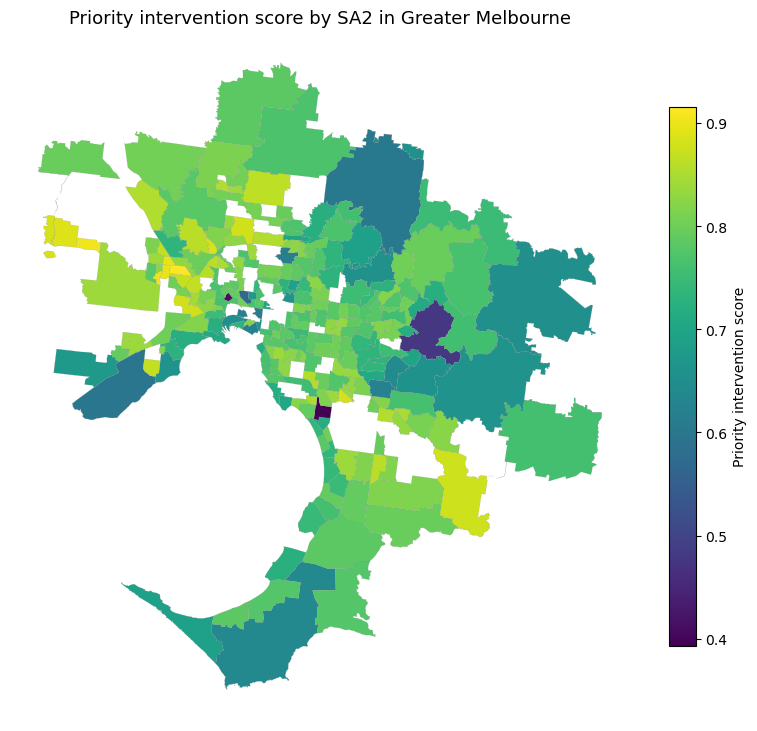

In [151]:

fig, ax = plt.subplots(figsize=(10, 10))

priority_result.plot(
    column="priority_score",
    legend=True,
    legend_kwds={
        "label": "Priority intervention score",
        "shrink": 0.7
    },
    edgecolor="grey",
    linewidth=0.1,
    ax=ax
)

ax.set_title(
    "Priority intervention score by SA2 in Greater Melbourne",
    fontsize=13
)

ax.axis("off")

plt.show()

**Figure X. Priority intervention score by SA2 in Greater Melbourne.**  
Higher values indicate SA2s with higher combined priority based on urban heat intensity, low open space coverage, low green space per person and social vulnerability.

### 7.6 Conclusion

This section developed a simple social vulnerability and priority intervention analysis at the SA2 level. The social vulnerability score was based on median household income, elderly population percentage, children population percentage and population density. These indicators were used to represent socio-economic capacity, heat sensitivity and population exposure.

The final priority intervention score combined social vulnerability with environmental indicators from Q2, including urban heat intensity, open space coverage and green space per person. The results show that priority areas are not only defined by high heat, but by the overlap between heat exposure, limited green space availability and social vulnerability.

This analysis is useful as a first-stage screening tool for urban greening and heat mitigation planning. However, the result should be interpreted carefully because it uses equal weighting, SA2-level data and only the 257 SA2 areas matched in the Q2 dataset. Future analysis could include tree canopy cover, park accessibility, building density and more detailed local-scale demographic data. Green space per person also has some high values in outer SA2 areas, so the standardised score may be affected by outliers.

## 8. Priority Intervention Analysis

This section combines green space, urban heat, and social vulnerability indicators to identify priority areas for future urban greening, public open space improvement, and climate resilience planning.

## 9. Discussion

## 10. Limitations

## 11. Sustainability and Resilience Recommendations

## 12. Conclusion



#3 13. Conclusion

## 14. References